In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import RegularGridInterpolator
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

from itertools import product
import matplotlib.colors as mcolors
from wrf_io import postproc

In [3]:
fontsize = 24
plt.rcParams['xtick.labelsize'] = 20 
plt.rcParams['ytick.labelsize'] = 20 

plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

In [4]:
casenames = [
r'sn030151_vn402010',
r'sn030151_vn351759',
r'sn030151_vn301508',
r'sn030151_vn251256',
r'sn030151_vn201005',
r'sn030151_vn150754',
r'sn030151_vn100503',
r'sn030151_vn050251',
r'sn030151_v000000',
r'sn030151_v050251',
r'sn030151_v100503',
r'sn030151_v150754',
r'sn030151_v201005',
r'sn030151_v251256',
r'sn030151_v301508',
r'sn030151_v351759',
r'sn030151_v402010',
r'sn020101_vn402010',
r'sn020101_vn351759',
r'sn020101_vn301508',
r'sn020101_vn251256',
r'sn020101_vn201005',
r'sn020101_vn150754',
r'sn020101_vn100503',
r'sn020101_vn050251',
r'sn020101_v000000',
r'sn020101_v050251',
r'sn020101_v100503',
r'sn020101_v150754',
r'sn020101_v201005',
r'sn020101_v251256',
r'sn020101_v301508',
r'sn020101_v351759',
r'sn020101_v402010',
r'sn010050_vn402010',
r'sn010050_vn351759',
r'sn010050_vn301508',
r'sn010050_vn251256',
r'sn010050_vn201005',
r'sn010050_vn150754',
r'sn010050_vn100503',
r'sn010050_vn050251',
r'sn010050_v000000',
r'sn010050_v050251',
r'sn010050_v100503',
r'sn010050_v150754',
r'sn010050_v201005',
r'sn010050_v251256',
r'sn010050_v301508',
r'sn010050_v351759',
r'sn010050_v402010',
r's000000_vn402010',
r's000000_vn351759',
r's000000_vn301508',
r's000000_vn251256',
r's000000_vn201005',
r's000000_vn150754',
r's000000_vn100503',
r's000000_vn050251',
r's000000_v000000',
r's000000_v050251',
r's000000_v100503',
r's000000_v150754',
r's000000_v201005',
r's000000_v251256',
r's000000_v301508',
r's000000_v351759',
r's000000_v402010',
r's010050_vn402010',
r's010050_vn351759',
r's010050_vn301508',
r's010050_vn251256',
r's010050_vn201005',
r's010050_vn150754',
r's010050_vn100503',
r's010050_vn050251',
r's010050_v000000',
r's010050_v050251',
r's010050_v100503',
r's010050_v150754',
r's010050_v201005',
r's010050_v251256',
r's010050_v301508',
r's010050_v351759',
r's010050_v402010',
r's020101_vn402010',
r's020101_vn351759',
r's020101_vn301508',
r's020101_vn251256',
r's020101_vn201005',
r's020101_vn150754',
r's020101_vn100503',
r's020101_vn050251',
r's020101_v000000',
r's020101_v050251',
r's020101_v100503',
r's020101_v150754',
r's020101_v201005',
r's020101_v251256',
r's020101_v301508',
r's020101_v351759',
r's020101_v402010',
r's030151_vn402010',
r's030151_vn351759',
r's030151_vn301508',
r's030151_vn251256',
r's030151_vn201005',
r's030151_vn150754',
r's030151_vn100503',
r's030151_vn050251',
r's030151_v000000',
r's030151_v050251',
r's030151_v100503',
r's030151_v150754',
r's030151_v201005',
r's030151_v251256',
r's030151_v301508',
r's030151_v351759',
r's030151_v402010',
]

In [5]:
U_loc   = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/U_loc.npy')
dir_loc = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/dir_loc.npy')
Uhub    = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/Uhub.npy')
wrf_rel = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_rel.npy')
wrf_vax = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_vax.npy')
wrf_vtn = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_vtn.npy')
wrf_cax = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_cax.npy')
wrf_cot = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_cot.npy')
wrf_ind = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_ind.npy')
wrf_thr = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_thr.npy')
wrf_pow = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_pow.npy')
shapiro = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/shapiro.npy')
wrf_tsr = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_tsr.npy')
Nelm    = np.load("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/rotor_dims_10MW.npz")['Nelm']
Nsct    = np.load("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/rotor_dims_10MW.npz")['Nsct']
rOverR  = np.load("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/rotor_dims_10MW.npz")['rOverR']
R       = np.load("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/rotor_dims_10MW.npz")['R']

In [6]:
x_temp = [0,1,2,3,4,5,6]
y_temp = [16,15,14,13,12,11,10,9,8,7,6,5,4,3,2,1,0]
coords = [pair for pair in product(x_temp, y_temp)]

In [7]:
# Define the specific equation (e.g., linear: y = a * x + b)
def madsen_func(CT, a, b, c):

    return a * CT**3 + b * CT**2 + c * CT

In [8]:
veer  = np.array([-80,-70,-60,-50,-40,-30,-20,-10,0,10,20,30,40,50,60,70,80])
shear = np.array([-6,-4,-2,0,2,4,6])

training = [pair for pair in product(shear, veer)]

indices_80 = [i for i, (s, v) in enumerate(training) if (v == -80 and abs(s) == 0)]
indices_70 = [i for i, (s, v) in enumerate(training) if (v == -70 and abs(s) == 0)]
indices_60 = [i for i, (s, v) in enumerate(training) if (v == -60 and abs(s) == 0)]
indices_50 = [i for i, (s, v) in enumerate(training) if (v == -50 and abs(s) == 0)]
indices_40 = [i for i, (s, v) in enumerate(training) if (v == -40 and abs(s) == 0)]
indices_30 = [i for i, (s, v) in enumerate(training) if (v == -30 and abs(s) == 0)]
indices_20 = [i for i, (s, v) in enumerate(training) if (v == -20 and abs(s) == 0)]
indices_10 = [i for i, (s, v) in enumerate(training) if (v == -10 and abs(s) == 0)]
indices_00 = [i for i, (s, v) in enumerate(training) if (v == 0 and abs(s) == 0)]

In [9]:
# V80

a_mom = np.linspace(0,0.05,10)
ct_mom = 4 * a_mom * (1 - a_mom)

a_mom = np.append(a_mom, wrf_ind[indices_80])
ct_mom = np.append(ct_mom, wrf_cot[indices_80])

# Perform curve fitting
params, covariance = curve_fit(madsen_func, ct_mom, a_mom)

# Extract fitted parameters
a_fit_v80, b_fit_v80, c_fit_v80 = params
# print(f"Fitted parameters: {a_fit_v80:.3f}, {b_fit_v80:.3f}, {c_fit_v80:.3f}")

np.save("/scratch/09909/smata/induction_modeling/madsen_modeling/rotor_coefficients/shapiro/vn80_10MW_rotor_coefficients.npy", [a_fit_v80,b_fit_v80,c_fit_v80])

# Generate fitted values
x_fit_v80 = np.linspace(0, 2, 100)
y_fit_v80 = madsen_func(x_fit_v80, a_fit_v80, b_fit_v80, c_fit_v80)

In [10]:
# V70

a_mom = np.linspace(0,0.05,10)
ct_mom = 4 * a_mom * (1 - a_mom)

a_mom = np.append(a_mom, wrf_ind[indices_70])
ct_mom = np.append(ct_mom, wrf_cot[indices_70])

# Perform curve fitting
params, covariance = curve_fit(madsen_func, ct_mom, a_mom)

# Extract fitted parameters
a_fit_v70, b_fit_v70, c_fit_v70 = params
# print(f"Fitted parameters: {a_fit_v70:.3f}, {b_fit_v70:.3f}, {c_fit_v70:.3f}")

np.save("/scratch/09909/smata/induction_modeling/madsen_modeling/rotor_coefficients/shapiro/vn70_10MW_rotor_coefficients.npy", [a_fit_v70,b_fit_v70,c_fit_v70])

# Generate fitted values
x_fit_v70 = np.linspace(0, 2, 100)
y_fit_v70 = madsen_func(x_fit_v70, a_fit_v70, b_fit_v70, c_fit_v70)

In [11]:
# V60

a_mom = np.linspace(0,0.05,10)
ct_mom = 4 * a_mom * (1 - a_mom)

a_mom = np.append(a_mom, wrf_ind[indices_60])
ct_mom = np.append(ct_mom, wrf_cot[indices_60])

# Perform curve fitting
params, covariance = curve_fit(madsen_func, ct_mom, a_mom)

# Extract fitted parameters
a_fit_v60, b_fit_v60, c_fit_v60 = params
# print(f"Fitted parameters: {a_fit_v70:.3f}, {b_fit_v70:.3f}, {c_fit_v70:.3f}")

np.save("/scratch/09909/smata/induction_modeling/madsen_modeling/rotor_coefficients/shapiro/vn60_10MW_rotor_coefficients.npy", [a_fit_v60,b_fit_v60,c_fit_v60])

# Generate fitted values
x_fit_v60 = np.linspace(0, 2, 100)
y_fit_v60 = madsen_func(x_fit_v60, a_fit_v60, b_fit_v60, c_fit_v60)

In [12]:
# V50

a_mom = np.linspace(0,0.05,10)
ct_mom = 4 * a_mom * (1 - a_mom)

a_mom = np.append(a_mom, wrf_ind[indices_50])
ct_mom = np.append(ct_mom, wrf_cot[indices_50])

# Perform curve fitting
params, covariance = curve_fit(madsen_func, ct_mom, a_mom)

# Extract fitted parameters
a_fit_v50, b_fit_v50, c_fit_v50 = params
# print(f"Fitted parameters: {a_fit_v70:.3f}, {b_fit_v70:.3f}, {c_fit_v70:.3f}")

np.save("/scratch/09909/smata/induction_modeling/madsen_modeling/rotor_coefficients/shapiro/vn50_10MW_rotor_coefficients.npy", [a_fit_v50,b_fit_v50,c_fit_v50])

# Generate fitted values
x_fit_v50 = np.linspace(0, 2, 100)
y_fit_v50 = madsen_func(x_fit_v50, a_fit_v50, b_fit_v50, c_fit_v50)

In [13]:
# V40

a_mom = np.linspace(0,0.05,10)
ct_mom = 4 * a_mom * (1 - a_mom)

a_mom = np.append(a_mom, wrf_ind[indices_40])
ct_mom = np.append(ct_mom, wrf_cot[indices_40])

# Perform curve fitting
params, covariance = curve_fit(madsen_func, ct_mom, a_mom)

# Extract fitted parameters
a_fit_v40, b_fit_v40, c_fit_v40 = params
# print(f"Fitted parameters: {a_fit_v40:.3f}, {b_fit_v40:.3f}, {c_fit_v40:.3f}")

np.save("/scratch/09909/smata/induction_modeling/madsen_modeling/rotor_coefficients/shapiro/vn40_10MW_rotor_coefficients.npy", [a_fit_v40,b_fit_v40,c_fit_v40])

# Generate fitted values
x_fit_v40 = np.linspace(0, 2, 100)
y_fit_v40 = madsen_func(x_fit_v40, a_fit_v40, b_fit_v40, c_fit_v40)

In [14]:
# V30

a_mom = np.linspace(0,0.05,10)
ct_mom = 4 * a_mom * (1 - a_mom)

a_mom = np.append(a_mom, wrf_ind[indices_30])
ct_mom = np.append(ct_mom, wrf_cot[indices_30])

# Perform curve fitting
params, covariance = curve_fit(madsen_func, ct_mom, a_mom)

# Extract fitted parameters
a_fit_v30, b_fit_v30, c_fit_v30 = params
# print(f"Fitted parameters: {a_fit_v40:.3f}, {b_fit_v40:.3f}, {c_fit_v40:.3f}")

np.save("/scratch/09909/smata/induction_modeling/madsen_modeling/rotor_coefficients/shapiro/vn30_10MW_rotor_coefficients.npy", [a_fit_v30,b_fit_v30,c_fit_v30])

# Generate fitted values
x_fit_v30 = np.linspace(0, 2, 100)
y_fit_v30 = madsen_func(x_fit_v30, a_fit_v30, b_fit_v30, c_fit_v30)

In [15]:
# V20

# a_mom = np.linspace(0,0.075,50)
a_mom = np.linspace(0,0.05,10)
ct_mom = 4 * a_mom * (1 - a_mom)

a_mom = np.append(a_mom, wrf_ind[indices_20])
ct_mom = np.append(ct_mom, wrf_cot[indices_20])

# a_mom = ind_rotor[indices_20]
# ct_mom = ct_rotor[indices_20]

# Perform curve fitting
params, covariance = curve_fit(madsen_func, ct_mom, a_mom)

# Extract fitted parameters
a_fit_v20, b_fit_v20, c_fit_v20 = params
# print(f"Fitted parameters: {a_fit_v20:.3f}, {b_fit_v20:.3f}, {c_fit_v20:.3f}")

np.save("/scratch/09909/smata/induction_modeling/madsen_modeling/rotor_coefficients/shapiro/vn20_10MW_rotor_coefficients.npy", [a_fit_v20,b_fit_v20,c_fit_v20])

# Generate fitted values
x_fit_v20 = np.linspace(0, 2, 100)
y_fit_v20 = madsen_func(x_fit_v20, a_fit_v20, b_fit_v20, c_fit_v20)

In [16]:
# V10

a_mom = np.linspace(0,0.05,10)
ct_mom = 4 * a_mom * (1 - a_mom)

a_mom = np.append(a_mom, wrf_ind[indices_10])
ct_mom = np.append(ct_mom, wrf_cot[indices_10])

# Perform curve fitting
params, covariance = curve_fit(madsen_func, ct_mom, a_mom)

# Extract fitted parameters
a_fit_v10, b_fit_v10, c_fit_v10 = params
# print(f"Fitted parameters: {a_fit_v10:.3f}, {b_fit_v10:.3f}, {c_fit_v10:.3f}")

np.save("/scratch/09909/smata/induction_modeling/madsen_modeling/rotor_coefficients/shapiro/vn10_10MW_rotor_coefficients.npy", [a_fit_v10,b_fit_v10,c_fit_v10])

# Generate fitted values
x_fit_v10 = np.linspace(0, 2, 100)
y_fit_v10 = madsen_func(x_fit_v10, a_fit_v10, b_fit_v10, c_fit_v10)

In [17]:
# V00

a_mom = np.linspace(0,0.05,10)
ct_mom = 4 * a_mom * (1 - a_mom)

a_mom = np.append(a_mom, wrf_ind[indices_00])
ct_mom = np.append(ct_mom, wrf_cot[indices_00])

# Perform curve fitting
params, covariance = curve_fit(madsen_func, ct_mom, a_mom)

# Extract fitted parameters
a_fit_v00, b_fit_v00, c_fit_v00 = params
# print(f"Fitted parameters: {a_fit_v00:.3f}, {b_fit_v00:.3f}, {c_fit_v00:.3f}")

np.save("/scratch/09909/smata/induction_modeling/madsen_modeling/rotor_coefficients/shapiro/v00_10MW_rotor_coefficients.npy", [a_fit_v00,b_fit_v00,c_fit_v00])

# Generate fitted values
x_fit_v00 = np.linspace(0, 2, 100)
y_fit_v00 = madsen_func(x_fit_v00, a_fit_v00, b_fit_v00, c_fit_v00)

In [18]:
print("if int(self.veer) == -8:")
print(f"    a,b,c = {a_fit_v80:.3f}, {b_fit_v80:.3f}, {c_fit_v80:.3f}")
print("elif int(self.veer) == -7:")
print(f"    a,b,c = {a_fit_v70:.3f}, {b_fit_v70:.3f}, {c_fit_v70:.3f}")
print("elif int(self.veer) == -6:")
print(f"    a,b,c = {a_fit_v60:.3f}, {b_fit_v60:.3f}, {c_fit_v60:.3f}")
print("elif int(self.veer) == -5:")
print(f"    a,b,c = {a_fit_v50:.3f}, {b_fit_v50:.3f}, {c_fit_v50:.3f}")
print("elif int(self.veer) == -4:")
print(f"    a,b,c = {a_fit_v40:.3f}, {b_fit_v40:.3f}, {c_fit_v40:.3f}")
print("elif int(self.veer) == -3:")
print(f"    a,b,c = {a_fit_v30:.3f}, {b_fit_v30:.3f}, {c_fit_v30:.3f}")
print("elif int(self.veer) == -2:")
print(f"    a,b,c = {a_fit_v20:.3f}, {b_fit_v20:.3f}, {c_fit_v20:.3f}")
print("elif int(self.veer) == -1:")
print(f"    a,b,c = {a_fit_v10:.3f}, {b_fit_v10:.3f}, {c_fit_v10:.3f}")
print("elif int(self.veer) == 0:")
print(f"    a,b,c = {a_fit_v00:.3f}, {b_fit_v00:.3f}, {c_fit_v00:.3f}")

if int(self.veer) == -8:
    a,b,c = 0.167, 0.028, 0.252
elif int(self.veer) == -7:
    a,b,c = 0.156, 0.031, 0.252
elif int(self.veer) == -6:
    a,b,c = 0.143, 0.034, 0.252
elif int(self.veer) == -5:
    a,b,c = 0.129, 0.038, 0.251
elif int(self.veer) == -4:
    a,b,c = 0.116, 0.041, 0.251
elif int(self.veer) == -3:
    a,b,c = 0.105, 0.044, 0.251
elif int(self.veer) == -2:
    a,b,c = 0.097, 0.047, 0.251
elif int(self.veer) == -1:
    a,b,c = 0.092, 0.048, 0.251
elif int(self.veer) == 0:
    a,b,c = 0.093, 0.048, 0.251


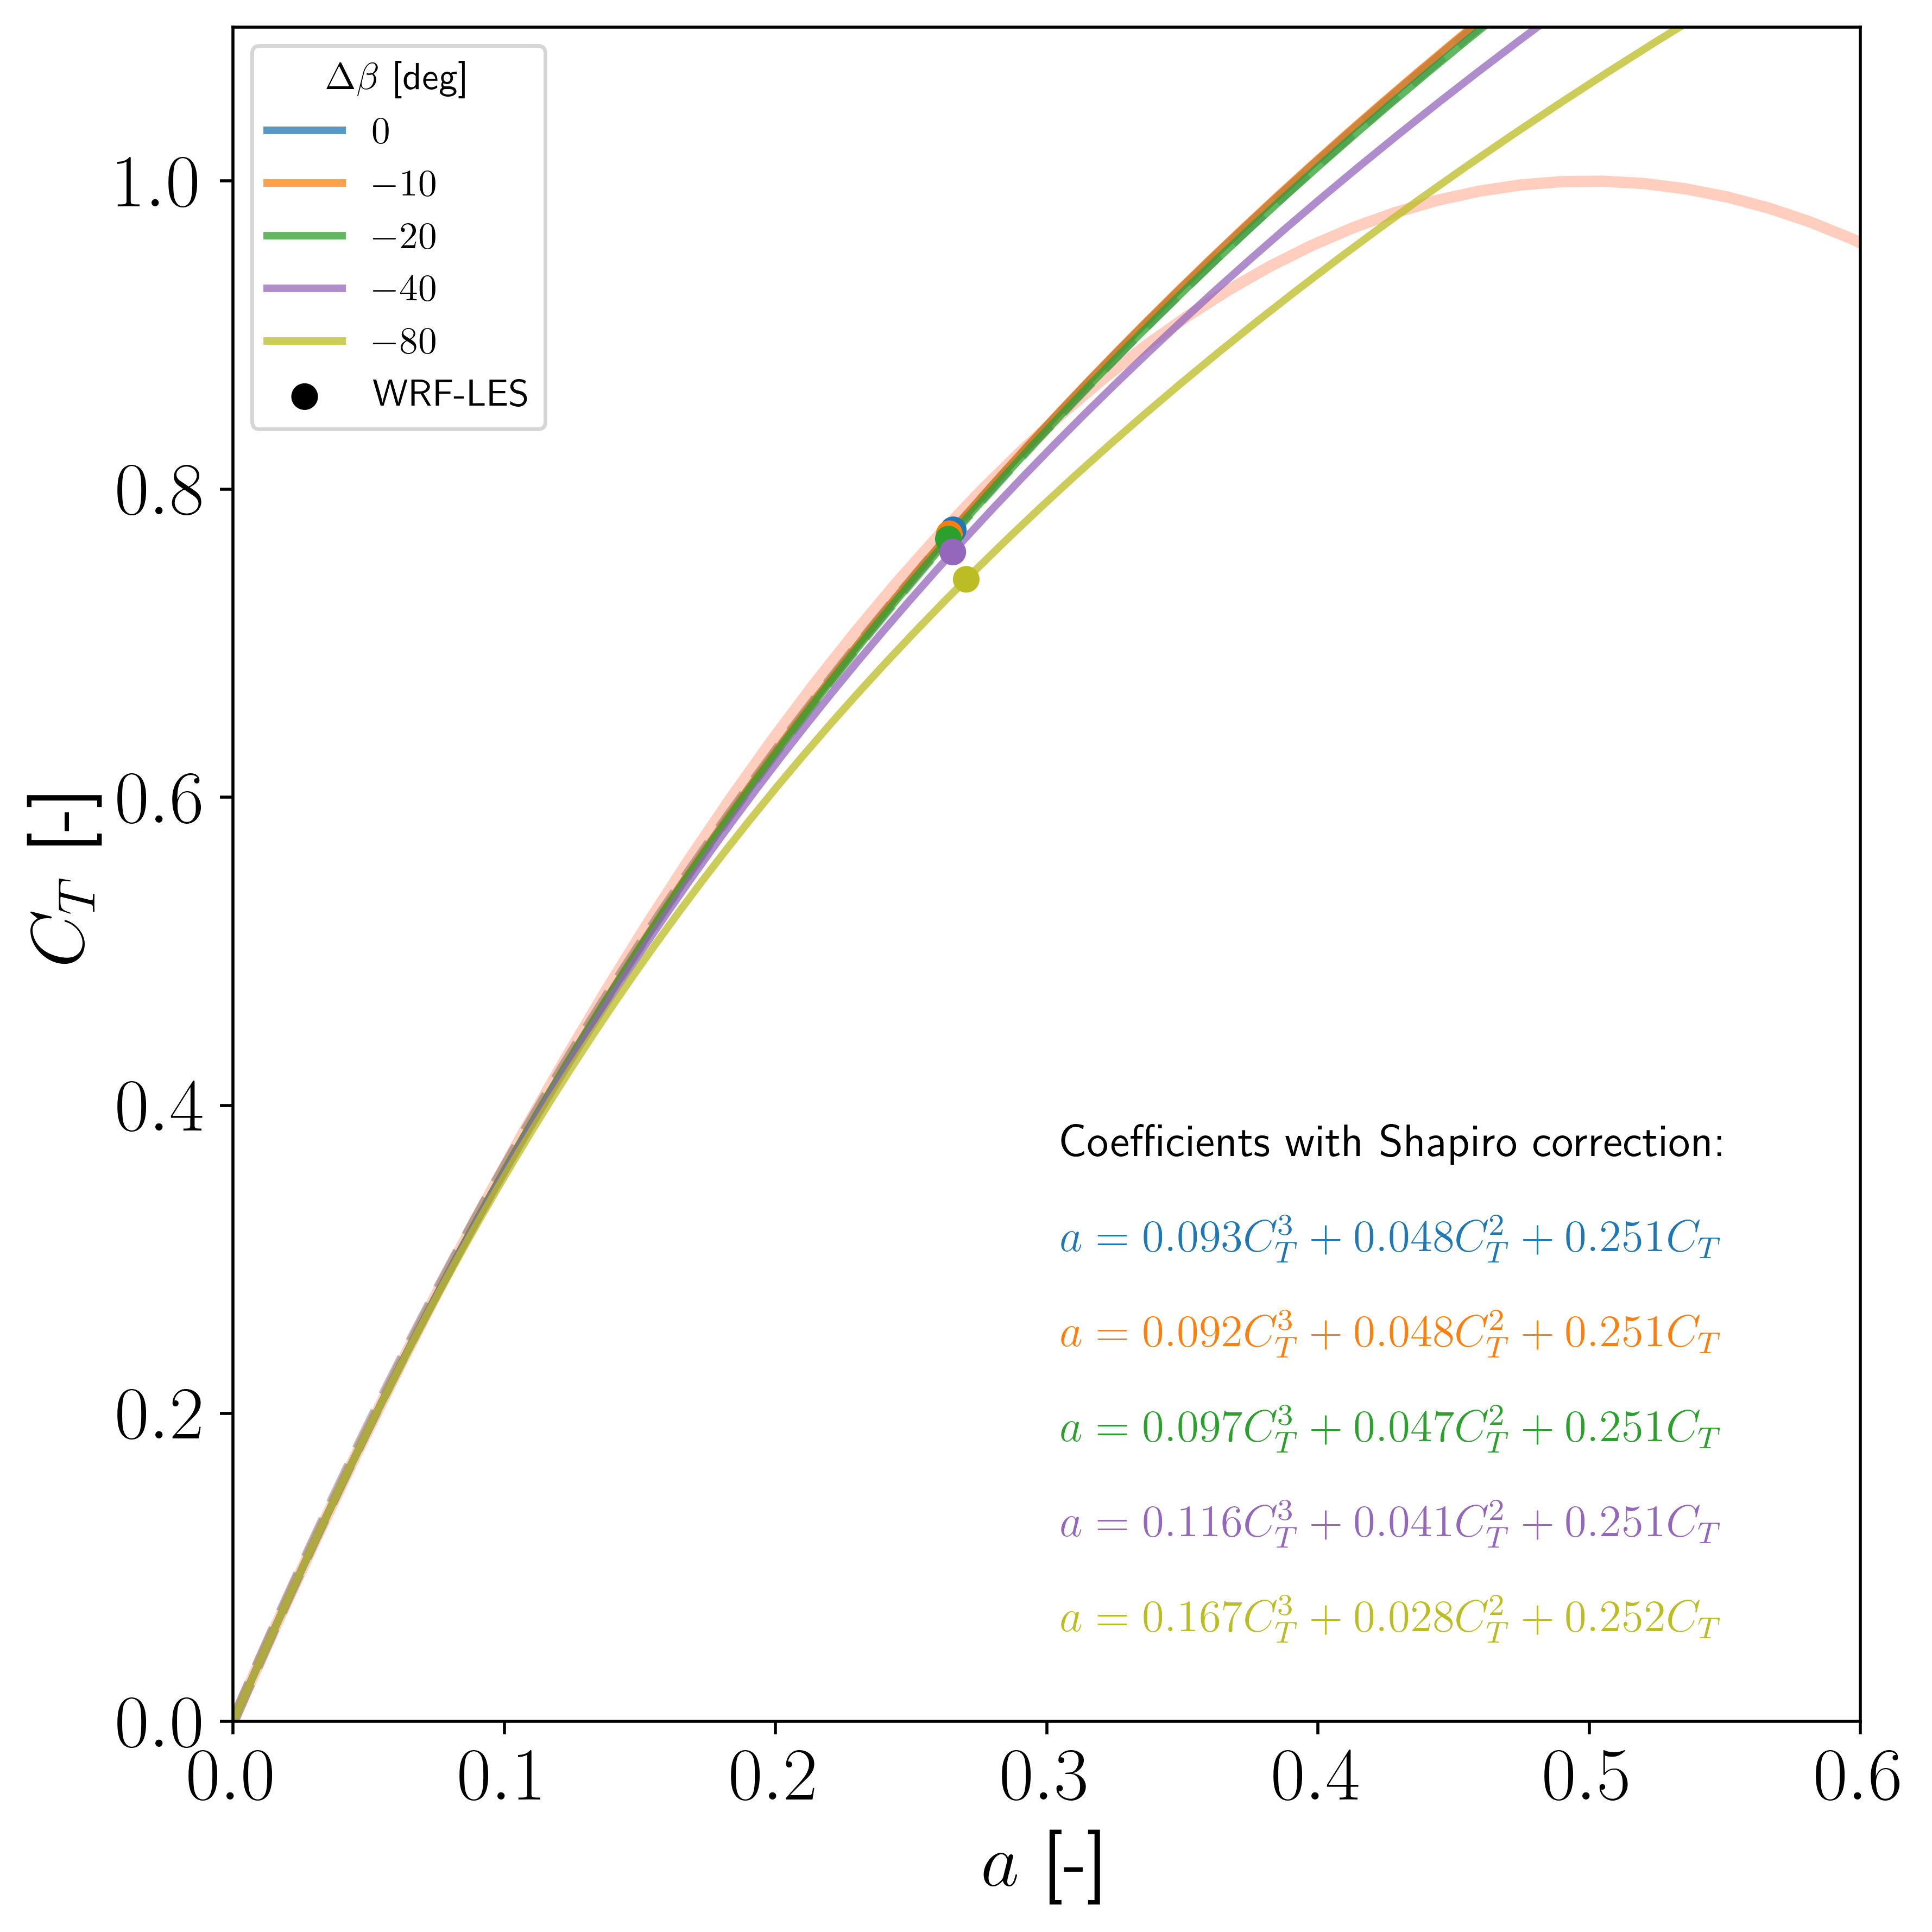

In [19]:
colors = sns.color_palette("tab10", 9)
# colors = colors[::-1]

fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True,sharex=True, sharey=True)
# fig, ax = plt.subplots(figsize=(5, 5), constrained_layout=True,sharex=True, sharey=True)

a_mom  = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)
ax.plot(a_mom, ct_mom, '#ff3c00',linewidth=3,zorder=1,alpha=0.25)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
ax.plot(a_mad, ct_mad, 'k--',linewidth=3,zorder=2,alpha=0.25)

ax.plot(y_fit_v00, x_fit_v00, color=colors[0],linewidth=2,zorder=2,alpha=0.75,label='$0$')
ax.plot(y_fit_v10, x_fit_v10, color=colors[1],linewidth=2,zorder=2,alpha=0.75,label='$-10$')
ax.plot(y_fit_v20, x_fit_v20, color=colors[2],linewidth=2,zorder=2,alpha=0.75,label='$-20$')
# ax.plot(y_fit_v30, x_fit_v30, color=colors[3],linewidth=2,zorder=2,alpha=0.75,label='$-30$')
ax.plot(y_fit_v40, x_fit_v40, color=colors[4],linewidth=2,zorder=2,alpha=0.75,label='$-40$')
# ax.plot(y_fit_v50, x_fit_v50, color=colors[5],linewidth=2,zorder=2,alpha=0.75,label='$-50$')
# ax.plot(y_fit_v60, x_fit_v60, color=colors[6],linewidth=2,zorder=2,alpha=0.75,label='$-80$')
# ax.plot(y_fit_v70, x_fit_v70, color=colors[7],linewidth=2,zorder=2,alpha=0.75,label='$-70$')
ax.plot(y_fit_v80, x_fit_v80, color=colors[8],linewidth=2,zorder=2,alpha=0.75,label='$-80$')

# ax.set_xlim([0.2,0.4])
# ax.set_ylim([0.5,1.0])

ax.set_xlim([0,0.6])
ax.set_ylim([0,1.1])

ax.set_ylabel('$C_T$ [-]', fontsize=20)
ax.set_xlabel('$a$ [-]', fontsize=20)

for i in range(len(indices_00)):
    mesh = ax.scatter(wrf_ind[indices_00[i]], wrf_cot[indices_00[i]], s=50, edgecolor='none',color=colors[0],zorder=3)

for i in range(len(indices_10)):
    mesh = ax.scatter(wrf_ind[indices_10[i]], wrf_cot[indices_10[i]], s=50, edgecolor='none',color=colors[1],zorder=3)

for i in range(len(indices_20)):
    mesh = ax.scatter(wrf_ind[indices_20[i]], wrf_cot[indices_20[i]], s=50, edgecolor='none',color=colors[2],zorder=3)

for i in range(len(indices_40)):
    mesh = ax.scatter(wrf_ind[indices_40[i]], wrf_cot[indices_40[i]], s=50, edgecolor='none',color=colors[4],zorder=3)

for i in range(len(indices_80)):
    mesh = ax.scatter(wrf_ind[indices_80[i]], wrf_cot[indices_80[i]], s=50, edgecolor='none',color=colors[8],zorder=3)

mesh = ax.scatter(-5, -5, s=50, edgecolor='none',color='k',label='WRF-LES')

ax.legend(title='$\Delta \\beta$ [deg]')

fig.text(0.55,0.40, f'Coefficients with Shapiro correction:', ha='left', fontsize=12,rotation=0,color='k')
fig.text(0.55,0.35, f'$a = {a_fit_v00:0.3f}C_T^3 + {b_fit_v00:0.3f}C_T^2 + {c_fit_v00:0.3f}C_T$', ha='left', fontsize=12,rotation=0,color=colors[0])
fig.text(0.55,0.30, f'$a = {a_fit_v10:0.3f}C_T^3 + {b_fit_v10:0.3f}C_T^2 + {c_fit_v10:0.3f}C_T$', ha='left', fontsize=12,rotation=0,color=colors[1])
fig.text(0.55,0.25, f'$a = {a_fit_v20:0.3f}C_T^3 + {b_fit_v20:0.3f}C_T^2 + {c_fit_v20:0.3f}C_T$', ha='left', fontsize=12,rotation=0,color=colors[2])
fig.text(0.55,0.20, f'$a = {a_fit_v40:0.3f}C_T^3 + {b_fit_v40:0.3f}C_T^2 + {c_fit_v40:0.3f}C_T$', ha='left', fontsize=12,rotation=0,color=colors[4])
fig.text(0.55,0.15, f'$a = {a_fit_v80:0.3f}C_T^3 + {b_fit_v80:0.3f}C_T^2 + {c_fit_v80:0.3f}C_T$', ha='left', fontsize=12,rotation=0,color=colors[8])

# plt.savefig(f"./figs/wrf_10MW_rotor.png", bbox_inches="tight", dpi=600)

plt.show()

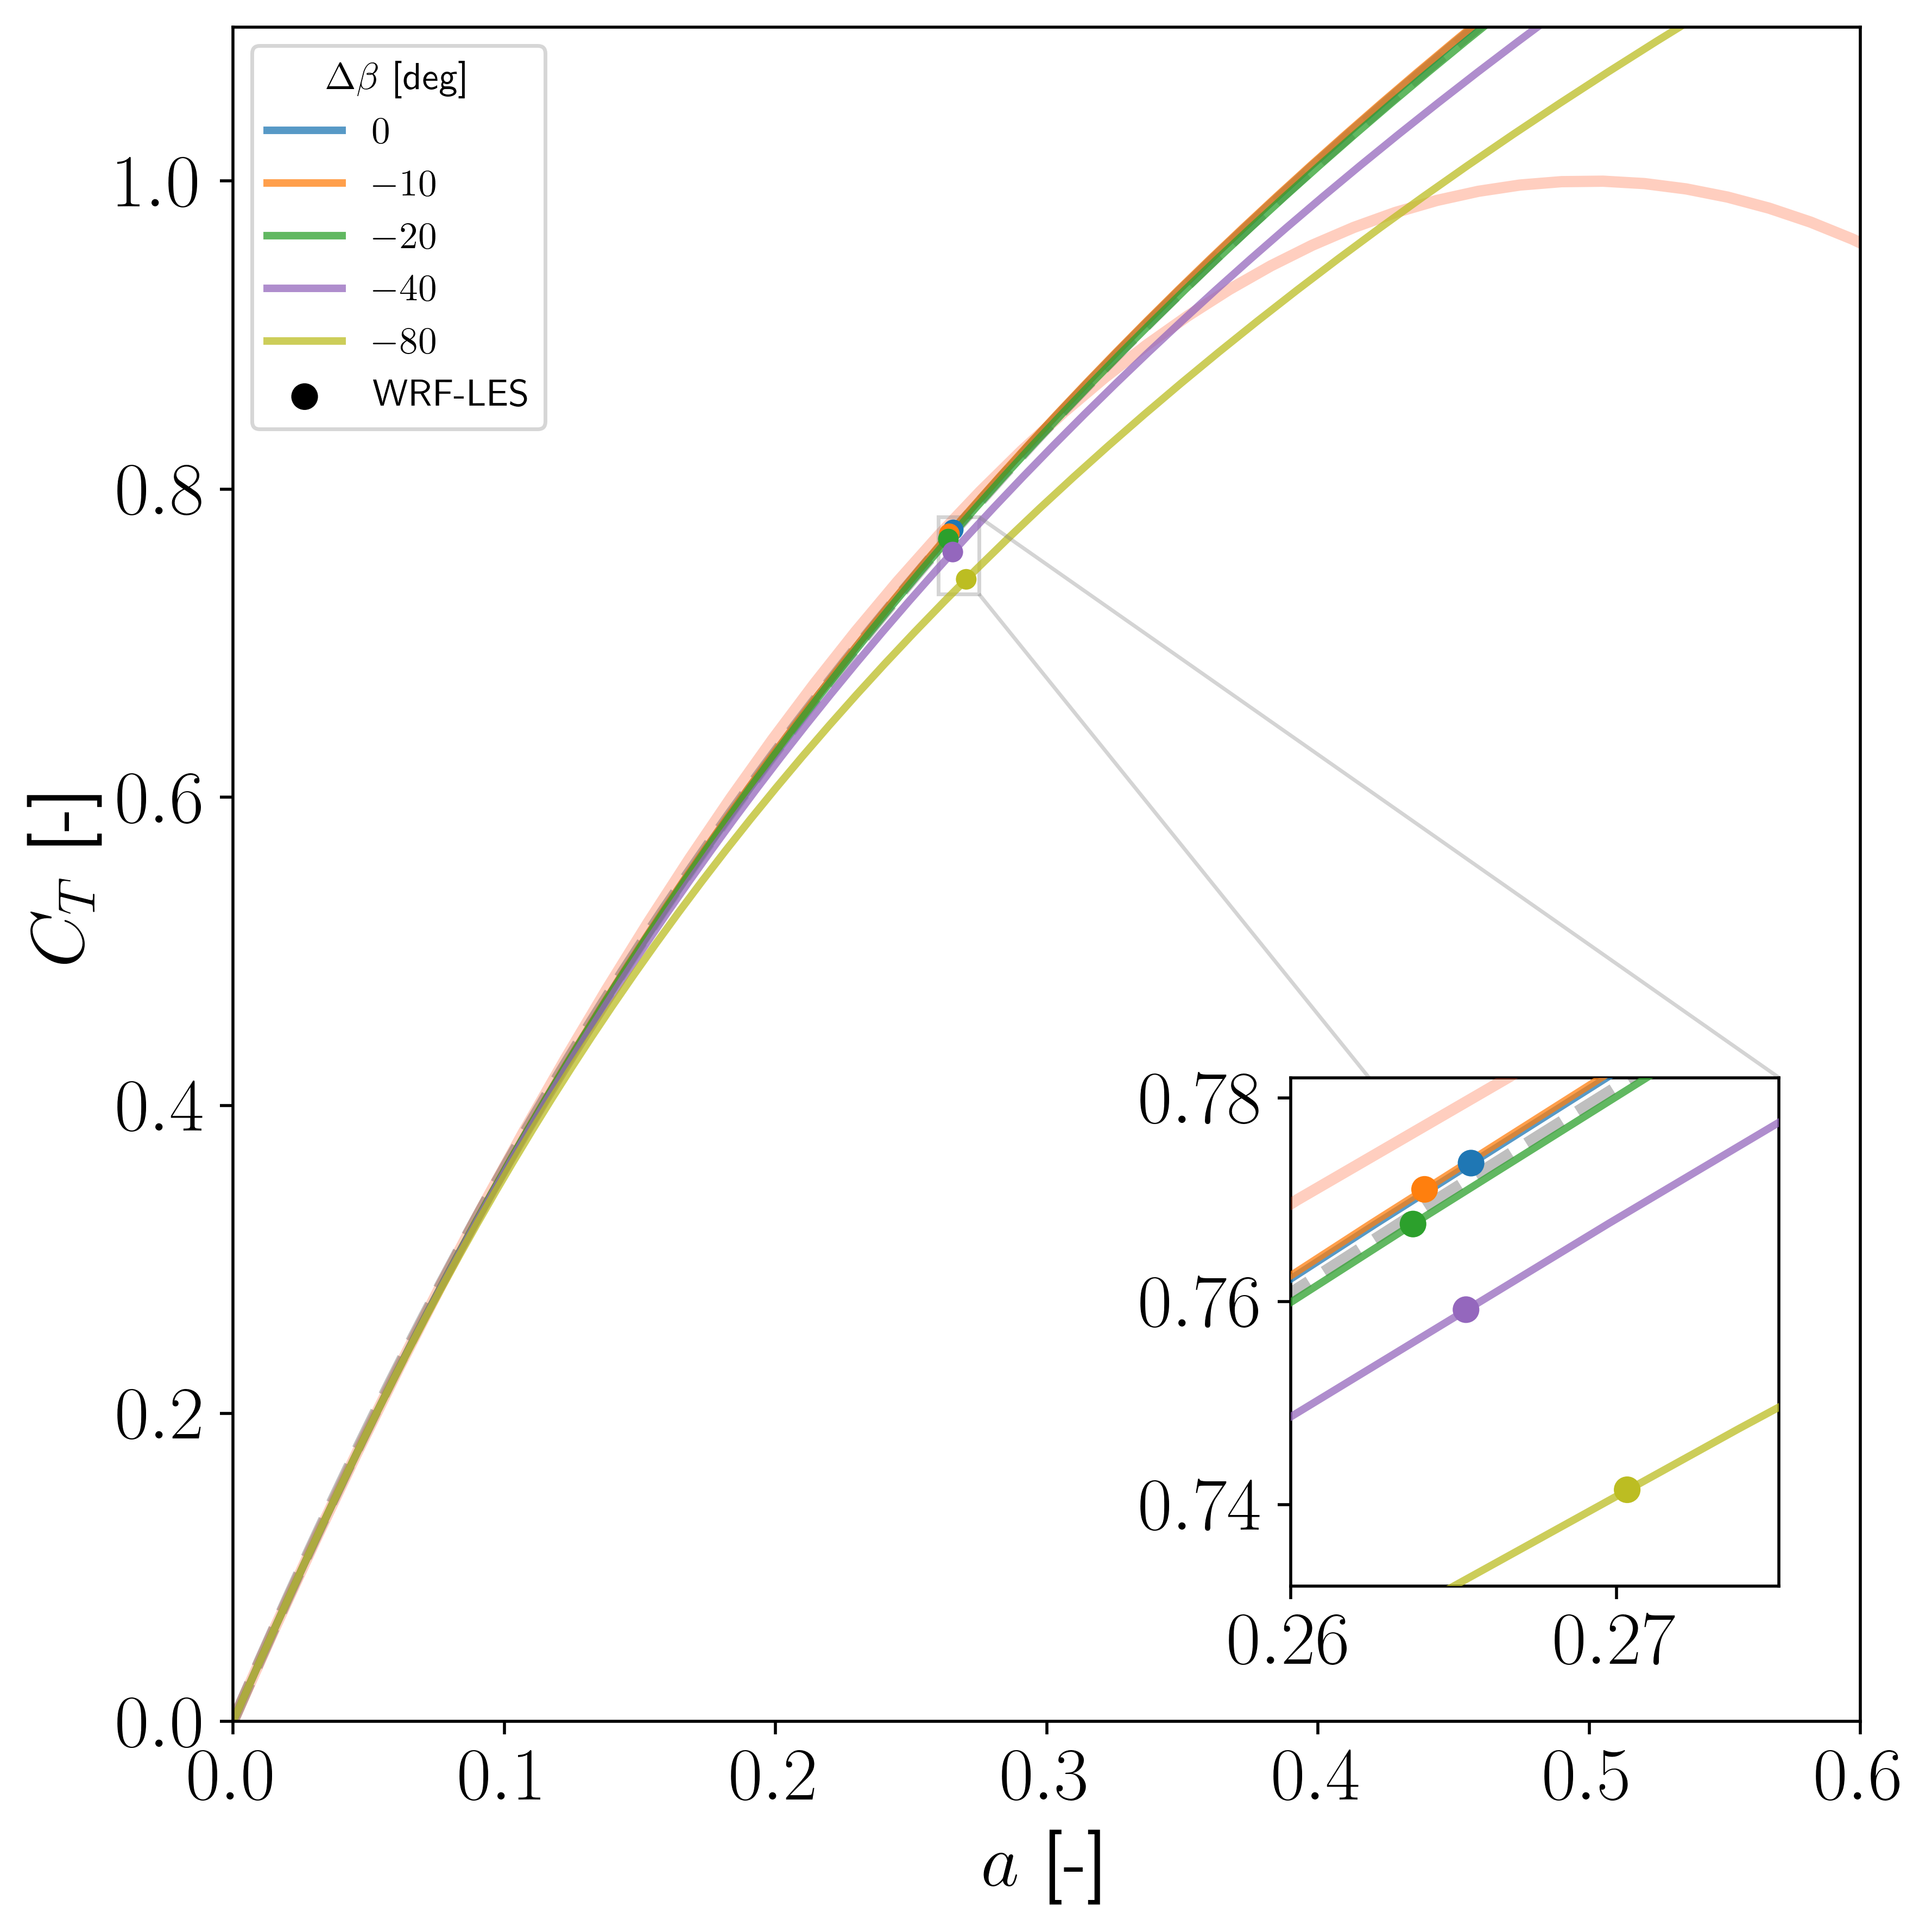

In [20]:
# Create the main figure and axis
fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)

a_mom  = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)
ax.plot(a_mom, ct_mom, '#ff3c00',linewidth=3,zorder=1,alpha=0.25)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
ax.plot(a_mad, ct_mad, 'k--',linewidth=3,zorder=2,alpha=0.25)

ax.plot(y_fit_v00, x_fit_v00, color=colors[0],linewidth=2,zorder=2,alpha=0.75,label='$0$')
ax.plot(y_fit_v10, x_fit_v10, color=colors[1],linewidth=2,zorder=2,alpha=0.75,label='$-10$')
ax.plot(y_fit_v20, x_fit_v20, color=colors[2],linewidth=2,zorder=2,alpha=0.75,label='$-20$')
ax.plot(y_fit_v40, x_fit_v40, color=colors[4],linewidth=2,zorder=2,alpha=0.75,label='$-40$')
ax.plot(y_fit_v80, x_fit_v80, color=colors[8],linewidth=2,zorder=2,alpha=0.75,label='$-80$')

ax.set_xlim([0,0.6])
ax.set_ylim([0,1.1])

ax.set_ylabel('$C_T$ [-]', fontsize=20)
ax.set_xlabel('$a$ [-]', fontsize=20)

for i in range(len(indices_00)):
    mesh = ax.scatter(wrf_ind[indices_00[i]], wrf_cot[indices_00[i]], s=30, edgecolor='none',color=colors[0],zorder=3)

for i in range(len(indices_10)):
    mesh = ax.scatter(wrf_ind[indices_10[i]], wrf_cot[indices_10[i]], s=30, edgecolor='none',color=colors[1],zorder=3)

for i in range(len(indices_20)):
    mesh = ax.scatter(wrf_ind[indices_20[i]], wrf_cot[indices_20[i]], s=30, edgecolor='none',color=colors[2],zorder=3)

for i in range(len(indices_40)):
    mesh = ax.scatter(wrf_ind[indices_40[i]], wrf_cot[indices_40[i]], s=30, edgecolor='none',color=colors[4],zorder=3)

for i in range(len(indices_80)):
    mesh = ax.scatter(wrf_ind[indices_80[i]], wrf_cot[indices_80[i]], s=30, edgecolor='none',color=colors[8],zorder=3)

mesh = ax.scatter(-5, -5, s=50, edgecolor='none',color='k',label='WRF-LES')

ax.legend(title='$\Delta \\beta$ [deg]')

# === Add inset axes ===
# Example: Zoom into a cluster near a=0.32, CT=0.7

inset_ax = ax.inset_axes(
   [0.65, 0.08, 0.3, 0.3],  # [x, y, width, height] w.r.t. axes
    xlim=[0.26, 0.275], ylim=[0.732, 0.782] # sets viewport & tells relation to main axes
    # xticklabels=[], yticklabels=[]
)

# # Plot the same data inside the inset
inset_ax.plot(a_mom, ct_mom, '#ff3c00', linewidth=3, alpha=0.25,zorder=3)
inset_ax.plot(a_mad, ct_mad, 'k--', linewidth=3, alpha=0.25,zorder=3)

# # Re-plot the fitted curves
inset_ax.plot(y_fit_v00, x_fit_v00, color=colors[0], linewidth=2, alpha=0.75,zorder=3)
inset_ax.plot(y_fit_v10, x_fit_v10, color=colors[1], linewidth=2, alpha=0.75,zorder=3)
inset_ax.plot(y_fit_v20, x_fit_v20, color=colors[2], linewidth=2, alpha=0.75,zorder=3)
inset_ax.plot(y_fit_v40, x_fit_v40, color=colors[4], linewidth=2, alpha=0.75,zorder=3)
inset_ax.plot(y_fit_v80, x_fit_v80, color=colors[8], linewidth=2, alpha=0.75,zorder=3)

import matplotlib.patches as patches

rect = patches.Rectangle((0.2, 0.6), 0.2, 0.2, facecolor='white', edgecolor='k',zorder=2)
inset_ax.add_patch(rect)

# Re-plot the scatter data
for i in indices_00:
    inset_ax.scatter(wrf_ind[i], wrf_cot[i], s=50, edgecolor='none', color=colors[0],zorder=4)
for i in indices_10:
    inset_ax.scatter(wrf_ind[i], wrf_cot[i], s=50, edgecolor='none', color=colors[1],zorder=4)
for i in indices_20:
    inset_ax.scatter(wrf_ind[i], wrf_cot[i], s=50, edgecolor='none', color=colors[2],zorder=4)
for i in indices_40:
    inset_ax.scatter(wrf_ind[i], wrf_cot[i], s=50, edgecolor='none', color=colors[4],zorder=4)
for i in indices_80:
    inset_ax.scatter(wrf_ind[i], wrf_cot[i], s=50, edgecolor='none', color=colors[8],zorder=4)

# Add a rectangle on the main plot showing the zoomed region
mark_inset(ax, inset_ax, loc1=1, loc2=4, fc="none", ec="0.5",zorder=1,alpha=1/3)

plt.show()

In [21]:
subset_indices = [i for i, (s, v) in enumerate(training) if (v <= 0 and abs(s) == 0)]
wrf_ref_index      = [i for i, (s, v) in enumerate(training) if (v == 0 and s == 0)]

wrf_pow_ss = np.zeros_like(subset_indices, dtype='float')
wrf_thr_ss = np.zeros_like(subset_indices, dtype='float')
wrf_cot_ss = np.zeros_like(subset_indices, dtype='float')
wrf_ind_ss = np.zeros_like(subset_indices, dtype='float')
wrf_rel_ss = np.zeros_like(subset_indices, dtype='float')
wrf_vax_ss = np.zeros_like(subset_indices, dtype='float')
wrf_vtn_ss = np.zeros_like(subset_indices, dtype='float')

for i in range(len(np.zeros_like(subset_indices, dtype='float'))):
    wrf_pow_ss[i] = wrf_pow[subset_indices[i]]
    wrf_thr_ss[i] = wrf_thr[subset_indices[i]]
    wrf_cot_ss[i] = wrf_cot[subset_indices[i]]
    wrf_ind_ss[i] = wrf_ind[subset_indices[i]]
    wrf_rel_ss[i] = wrf_rel[subset_indices[i]]
    wrf_vax_ss[i] = wrf_vax[subset_indices[i]]
    wrf_vtn_ss[i] = wrf_vtn[subset_indices[i]]

In [52]:
wrf_power_dev     = postproc.per_error(wrf_pow_ss, wrf_pow[wrf_ref_index])
wrf_thrust_dev    = postproc.per_error(wrf_thr_ss, wrf_thr[wrf_ref_index])
wrf_induction_dev = postproc.per_error(wrf_ind_ss, wrf_ind[wrf_ref_index])

np.savez("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_dim_negV_NoS.npz", pow=wrf_pow_ss, thr=wrf_thr_ss, ind=wrf_ind_ss)

np.savez("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_dev_negV_NoS.npz", pow=wrf_power_dev, thr=wrf_thrust_dev, ind=wrf_induction_dev)

In [23]:
replacements = {
    'sn030151': 'sn06',
    'sn020101': 'sn04',
    'sn010050': 'sn02',
    's000000' : 's00',
    's010050' : 's02',
    's020101' : 's04',
    's030151' : 's06',
    'vn402010' : 'vn80',
    'vn351759' : 'vn70',
    'vn301508' : 'vn60',
    'vn251256' : 'vn50',
    'vn201005' : 'vn40',
    'vn150754' : 'vn30',
    'vn100503' : 'vn20',
    'vn050251' : 'vn10',
    'v000000'  : 'v00',
    'v050251'  : 'v10',
    'v100503'  : 'v20',
    'v150754'  : 'v30',
    'v201005'  : 'v40',
    'v251256'  : 'v50',
    'v301508'  : 'v60',
    'v351759'  : 'v70',
    'v402010'  : 'v80'
}

In [24]:
n_levels = 100

pow_levels = plt.colormaps['seismic'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=-5, vmax=5)  # Normalize power to [0, 1]
pow_cmap = [pow_levels(int(norm(p) * (n_levels - 1))) for p in wrf_power_dev]  # Map power to discrete colors

thr_levels = plt.colormaps['PiYG'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=-7, vmax=7)  # Normalize power to [0, 1]
thr_cmap = [thr_levels(int(norm(t) * (n_levels - 1))) for t in wrf_thrust_dev]  # Map power to discrete colors

ind_levels = plt.colormaps['Spectral'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=-3, vmax=3)  # Normalize power to [0, 1]
ind_cmap = [ind_levels(int(norm(a) * (n_levels - 1))) for a in wrf_induction_dev]  # Map power to discrete colors

In [25]:
sub_cases = [np.array(casenames)[subset_indices]]

formatted_cases = []
for name in sub_cases[0]:
    for old, new in replacements.items():
        if old in name:
            name = name.replace(old, new)
    formatted_cases.append(name)

# Result
new_names = np.array(formatted_cases)

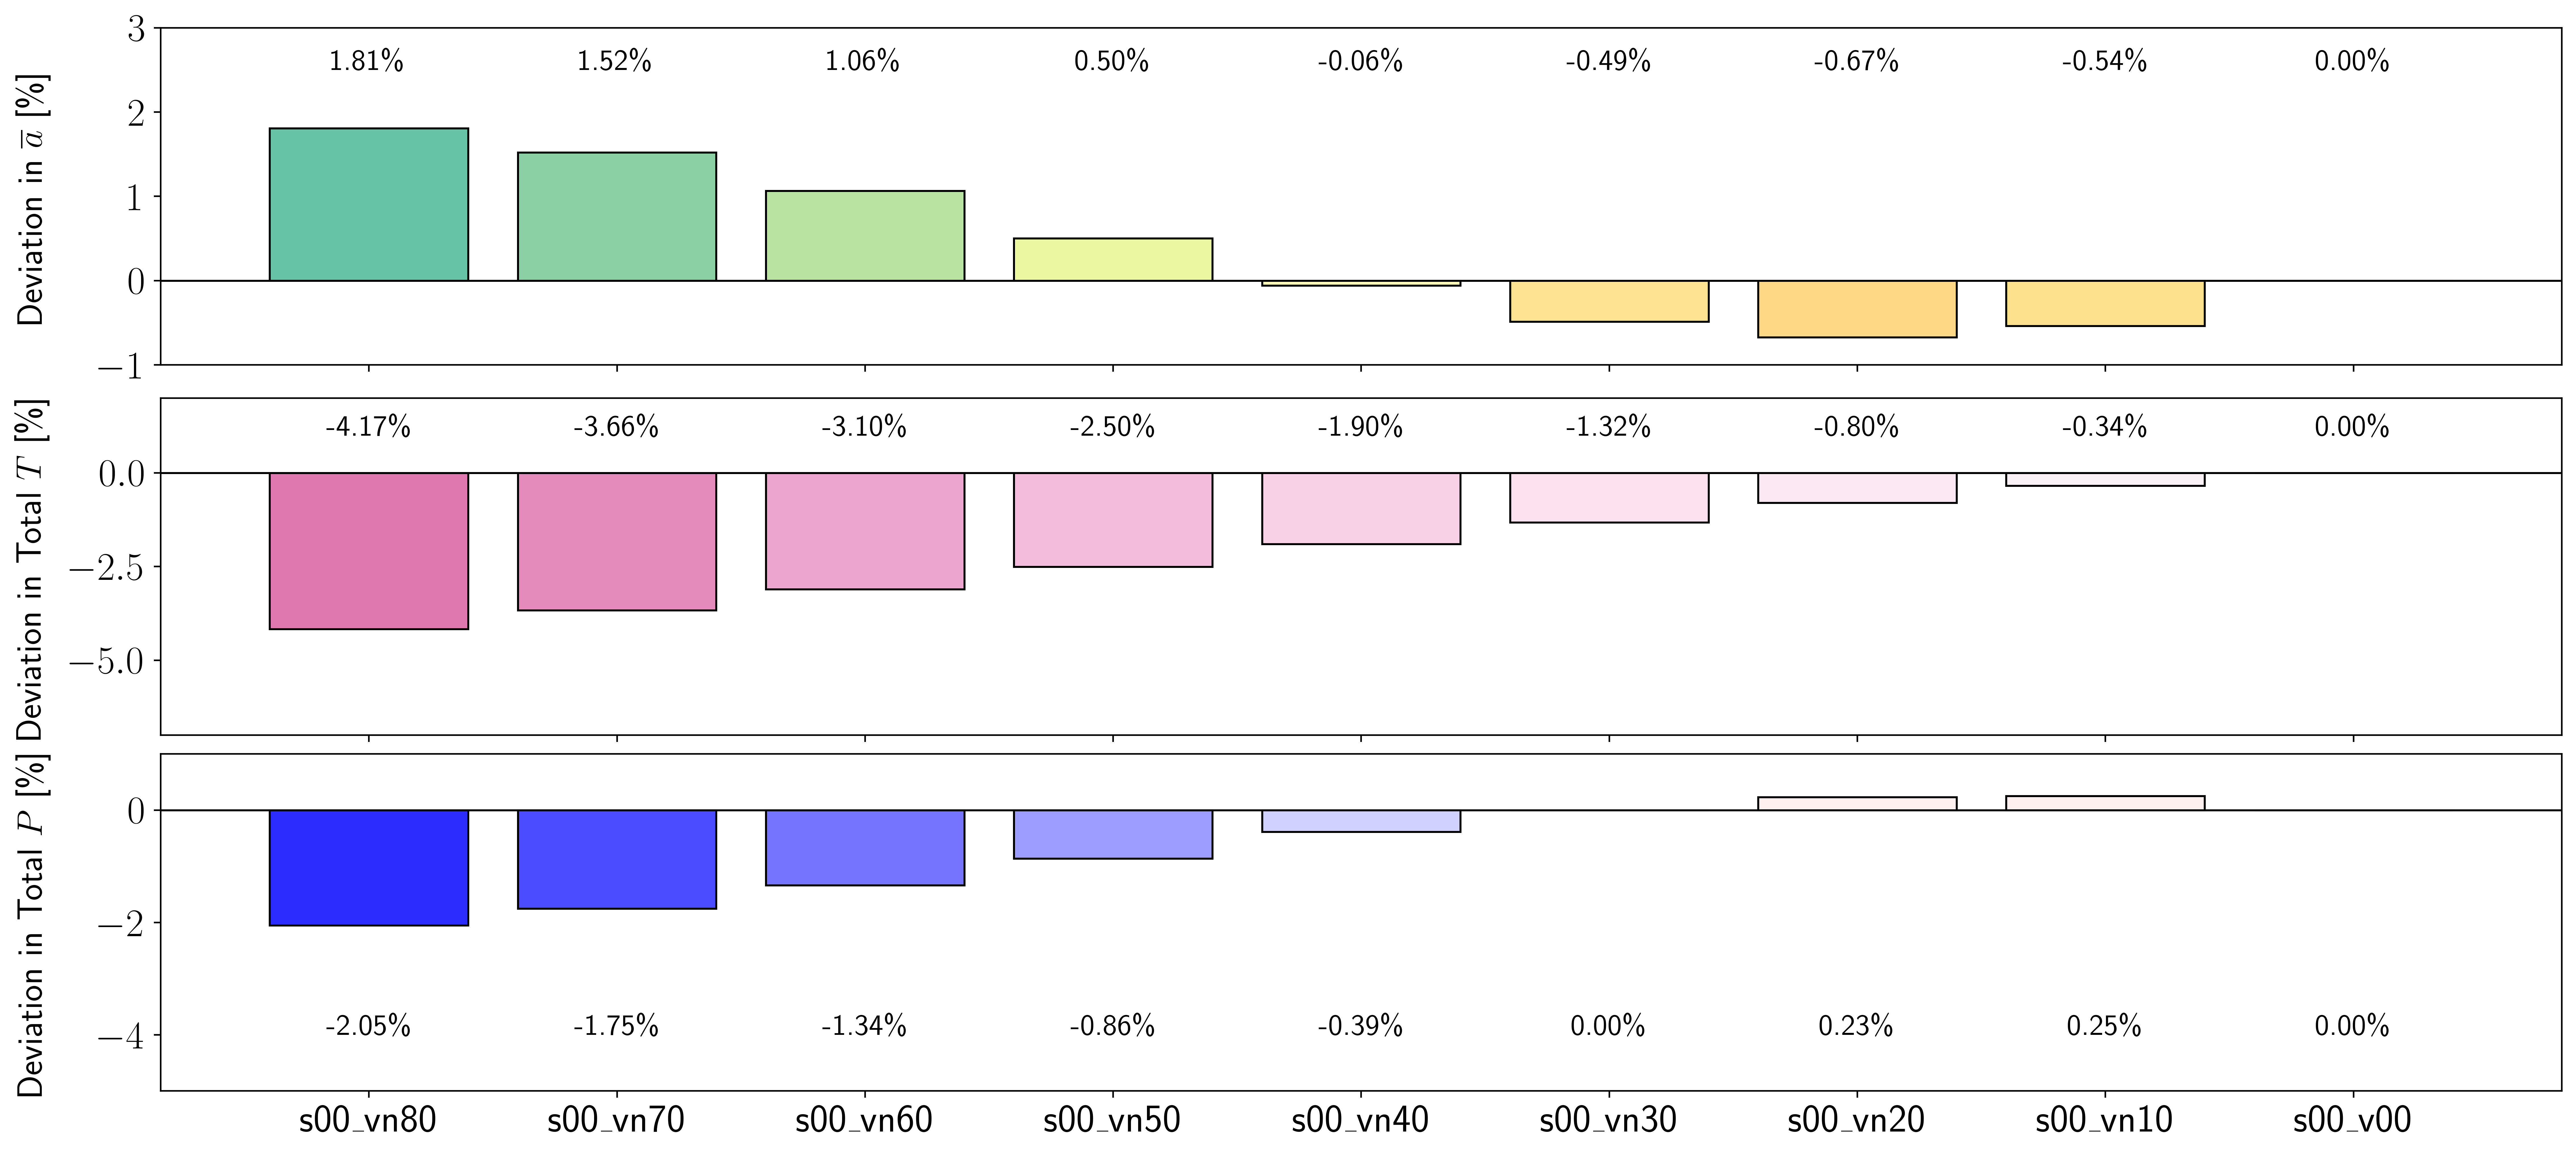

In [26]:
width = 0.75
alpha = 1.0

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, constrained_layout = True)
ax[0].axhline(0, color='black', linestyle='solid', linewidth=1)
ax[1].axhline(0, color='black', linestyle='solid', linewidth=1)
ax[2].axhline(0, color='black', linestyle='solid', linewidth=1)

ind = np.arange(len(new_names))

for count in range(len(new_names)):

    # induction
    ax[0].bar(ind[count], wrf_induction_dev[count], color=ind_cmap[count], edgecolor='black', alpha=alpha)
    ax[0].set_ylabel(r'Deviation in ${\overline{a}}$ [\%]', fontsize=fontsize*0.75, labelpad=24)
    ax[0].text(ind[count], 2.5, f'{wrf_induction_dev[count]:0.2f}\%', ha='center', fontsize=15)
    ax[0].set_ylim([-1,3])

    # thrust
    ax[1].bar(ind[count], wrf_thrust_dev[count], color=thr_cmap[count], edgecolor='black', alpha=alpha)
    ax[1].set_ylabel(r'Deviation in Total $T$ [\%]', fontsize=fontsize*0.75, labelpad=10)
    ax[1].text(ind[count], 1, f'{wrf_thrust_dev[count]:0.2f}\%', ha='center', fontsize=15)
    ax[1].set_ylim([-7,2])

    # power
    ax[2].bar(ind[count], wrf_power_dev[count], color=pow_cmap[count], edgecolor='black', alpha=alpha)
    ax[2].set_xticks(ind)
    ax[2].set_xticklabels(new_names)
    ax[2].set_ylabel(r'Deviation in Total $P$ [\%]', fontsize=fontsize*0.75, labelpad=24)
    ax[2].text(ind[count], -4, f'{wrf_power_dev[count]:0.2f}\%', ha='center', fontsize=15)
    ax[2].set_ylim([-5,1])

# plt.savefig("/scratch/09909/smata/wrf_les_sweep/runs/clockwise/gad_sweep/figs/rel_err_ind_thrust_torque_power.png", bbox_inches="tight", dpi=800)
plt.show()

In [27]:
from MITRotor import BEM, IEA10MW, NoTipLoss, KraghAerodynamics, NoTangentialInduction, Madsen_Rotor_Momentum_NegV_NoS

In [28]:
rotor = IEA10MW()
veers = (np.array(training)[subset_indices][:, 1]/10).astype(int)

mit_ind = np.zeros_like(subset_indices, dtype='float')
mit_cot = np.zeros_like(subset_indices, dtype='float')
mit_thr = np.zeros_like(subset_indices, dtype='float')
mit_cop = np.zeros_like(subset_indices, dtype='float')
mit_pow = np.zeros_like(subset_indices, dtype='float')
iters   = np.zeros_like(subset_indices, dtype='float')

mit_w   = np.zeros_like(subset_indices, dtype='float')
mit_cax = np.zeros_like(subset_indices, dtype='float')
mit_vax = np.zeros_like(subset_indices, dtype='float')
mit_vtn = np.zeros_like(subset_indices, dtype='float')

for count in range(len(subset_indices)):

    bem = BEM(rotor=rotor, aerodynamic_model=KraghAerodynamics(), tiploss_model=NoTipLoss(), momentum_model=Madsen_Rotor_Momentum_NegV_NoS(veer=veers[count]), tangential_induction_model=NoTangentialInduction())

    tsr = wrf_tsr[count] * rotor.R / R

    t = np.linspace(0,2*np.pi,Nsct)
    r = rOverR

    interpU = RegularGridInterpolator(
    (r, t), U_loc[:,:,subset_indices[count]], bounds_error=False, fill_value=None
    )

    interpW = RegularGridInterpolator(
    (r, t), dir_loc[:,:,subset_indices[count]], bounds_error=False, fill_value=None
    )

    t_new = np.linspace(0,2*np.pi,20)
    r_new = np.linspace(0,1,10)

    R_new, T_new = np.meshgrid(r_new, t_new, indexing='ij')

    points = np.column_stack((R_new.ravel(), T_new.ravel()))  # shape (Nr*Nt, 2)
    U_interp_flat = interpU(points)
    W_interp_flat = interpW(points)
    U_interp = U_interp_flat.reshape(R_new.shape)
    W_interp = W_interp_flat.reshape(R_new.shape)

    r_dim = r_new * rotor.R

    sol = bem(0, tsr-0.3, 0, U = U_interp, wdir=W_interp,veer=veers[count])
    # sol = bem(0, tsr, 0, U = U_interp, wdir=W_interp,veer=veers[count])

    rho = 1.225

    Nr = 10  # number of radial points
    Ntheta = 20  # number of azimuthal points
    r =np.linspace(0,1,10) * rotor.R
    theta = sol.geom.theta_mesh[0,:]
    R_grid, Theta_grid = np.meshgrid(r, theta, indexing='ij')  # shape (Nr, Ntheta)

    # Compute local area element: dA = r * dr * dθ
    dr = rotor.R / (Nr - 1)
    dtheta = 2 * np.pi / Ntheta
    dA = R_grid * dr * dtheta  # shape (Nr, Ntheta)

    # Compute total thrust
    integrand = 0.5 * rho * (sol.U('sector')*np.cos(sol.wdir('sector'))*7)**2 * sol.Ct('sector') * dA
    T_total = np.sum(integrand)

    local_power = 0.5 * rho * (sol.U('sector')*np.cos(sol.wdir('sector'))*7)**3 * sol.Cp('sector') * dA

    P_total = np.sum(local_power)

    mit_cot[count] = sol.Ct()
    mit_thr[count] = T_total/1e3
    mit_pow[count] = P_total/1e6
    mit_cop[count] = sol.Cp()
    mit_ind[count] = sol.a()
    iters[count]   = sol.niter
    mit_w[count]   = sol.W()
    mit_cax[count] = sol.Cx()
    mit_vax[count] = sol.Vax()
    mit_vtn[count] = sol.Vtan()
    
iters

array([4., 4., 3., 3., 3., 3., 3., 3., 3.])

In [53]:
mit_ref_index = np.where(veers == 0)[0]

mit_power_dev     = postproc.per_error(mit_cop, mit_cop[mit_ref_index])
mit_thrust_dev    = postproc.per_error(mit_cot, mit_cot[mit_ref_index])
mit_induction_dev = postproc.per_error(mit_ind, mit_ind[mit_ref_index])

np.savez("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/mitrotor_dim_negV_NoS.npz", pow=mit_pow, thr=mit_thr, ind=mit_ind)

np.savez("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/mitrotor_dev_negV_NoS.npz", pow=mit_power_dev, thr=mit_thrust_dev, ind=mit_induction_dev)

np.save("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/cases_negV_NoS.npy", new_names)

In [30]:
n_levels = 100

pow_levels = plt.colormaps['seismic'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=-5, vmax=5)  # Normalize power to [0, 1]
pow_cmap = [pow_levels(int(norm(p) * (n_levels - 1))) for p in mit_power_dev]  # Map power to discrete colors

thr_levels = plt.colormaps['PiYG'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=-7, vmax=7)  # Normalize power to [0, 1]
thr_cmap = [thr_levels(int(norm(t) * (n_levels - 1))) for t in mit_thrust_dev]  # Map power to discrete colors

ind_levels = plt.colormaps['Spectral'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=-3, vmax=3)  # Normalize power to [0, 1]
ind_cmap = [ind_levels(int(norm(a) * (n_levels - 1))) for a in mit_induction_dev]  # Map power to discrete colors

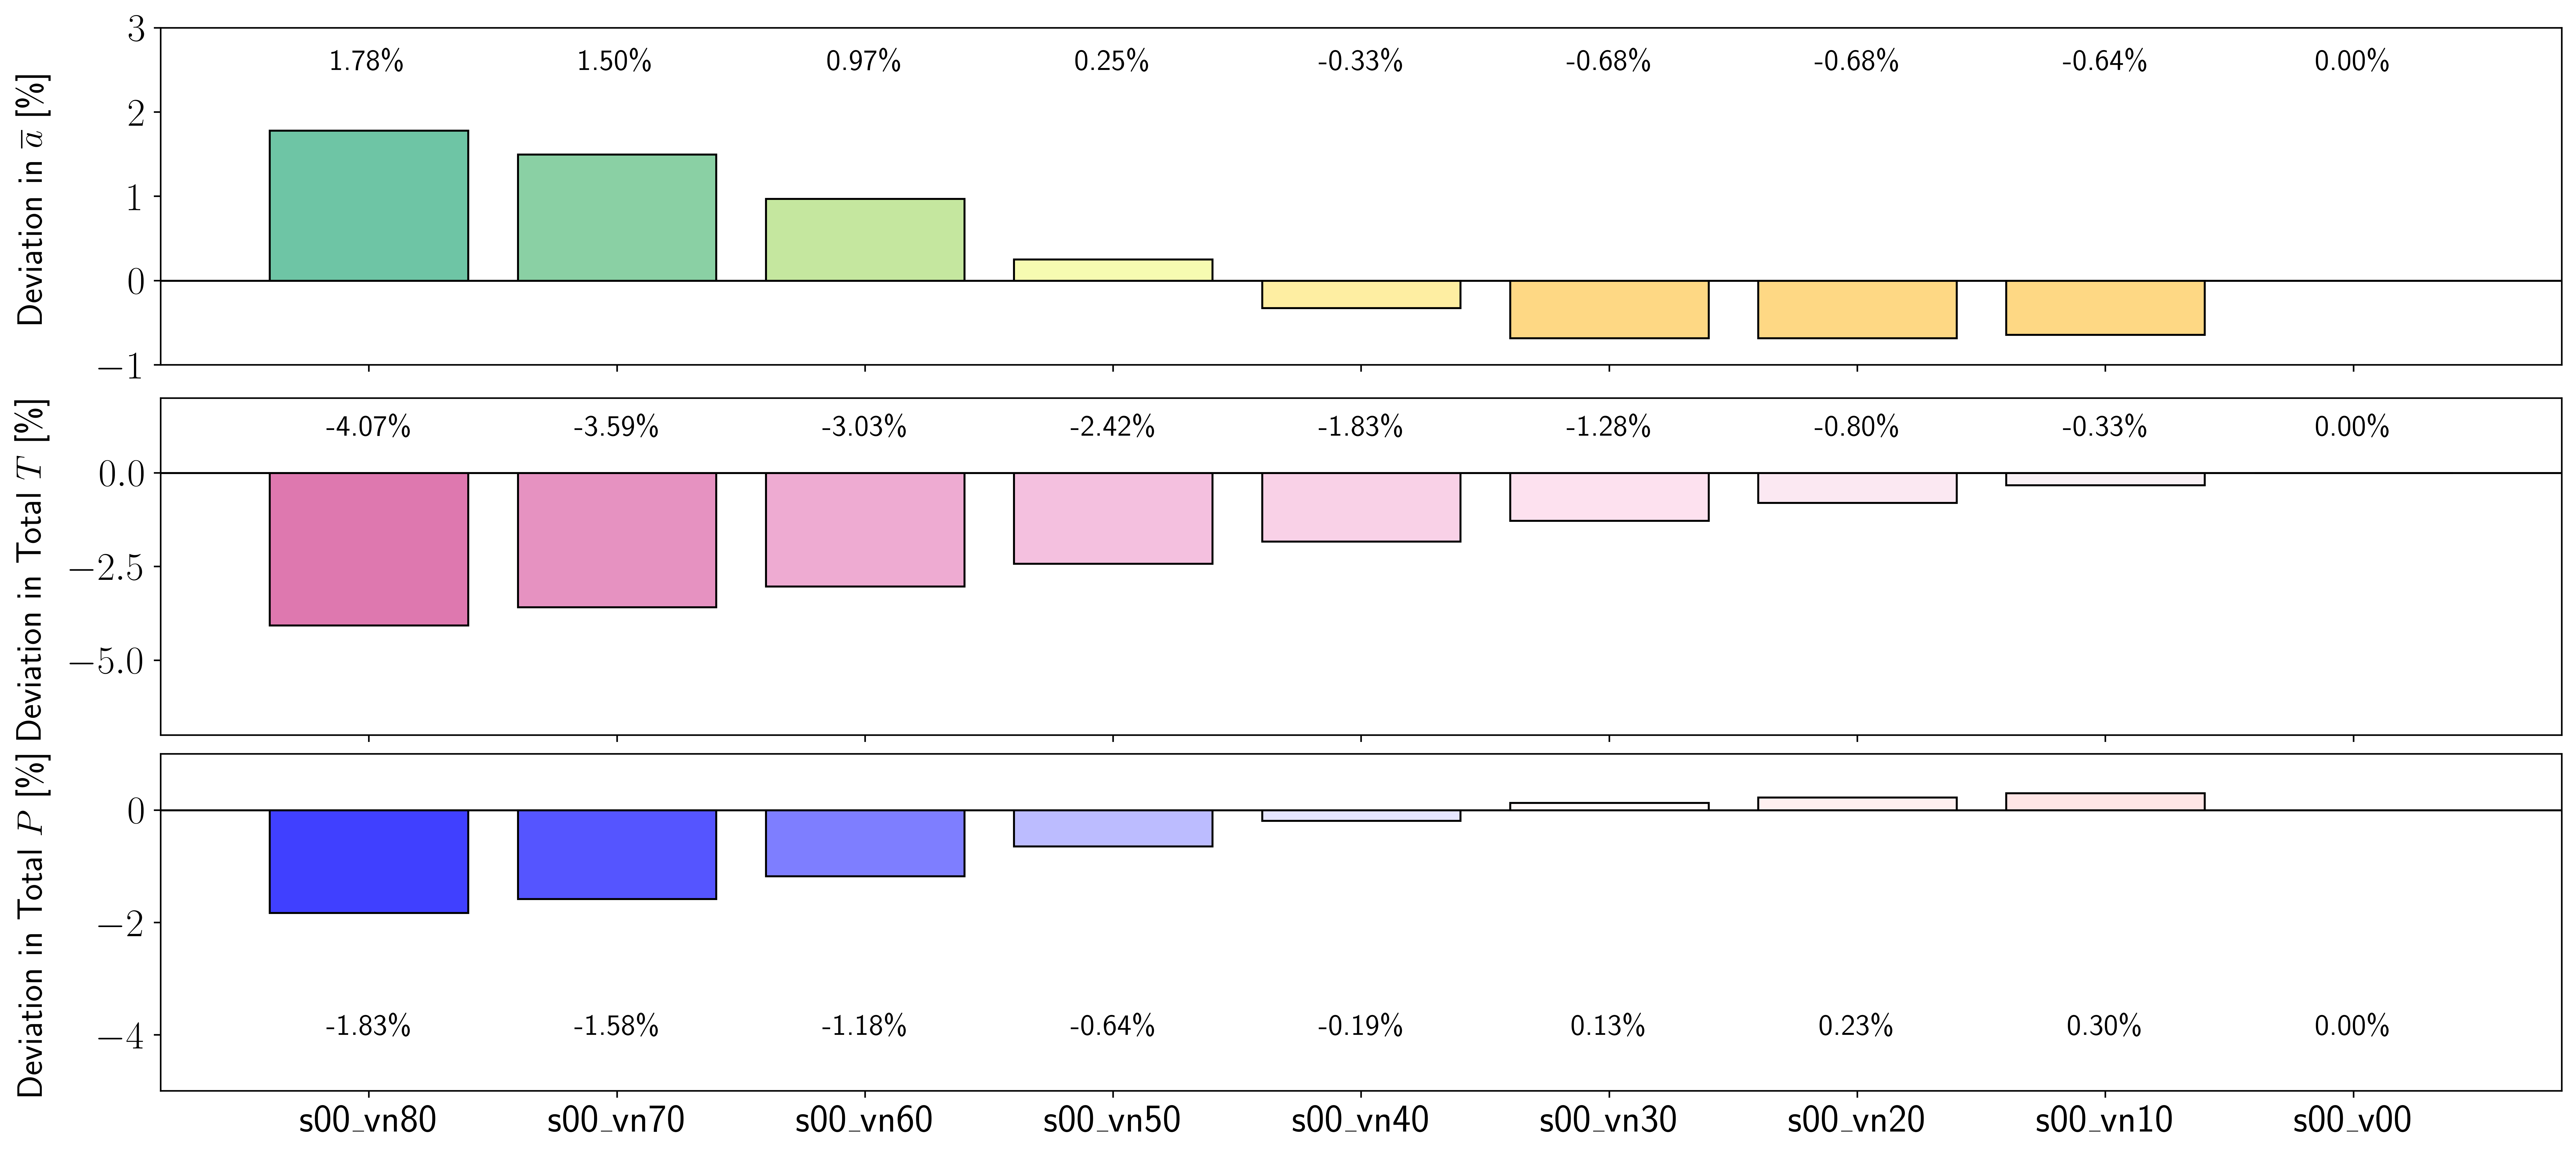

In [31]:
width = 0.75
alpha = 1.0

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, constrained_layout = True)
ax[0].axhline(0, color='black', linestyle='solid', linewidth=1)
ax[1].axhline(0, color='black', linestyle='solid', linewidth=1)
ax[2].axhline(0, color='black', linestyle='solid', linewidth=1)

ind = np.arange(len(new_names))

for count in range(len(new_names)):

    # induction
    ax[0].bar(ind[count], mit_induction_dev[count], color=ind_cmap[count], edgecolor='black', alpha=alpha)
    ax[0].set_ylabel(r'Deviation in ${\overline{a}}$ [\%]', fontsize=fontsize*0.75, labelpad=24)
    ax[0].text(ind[count],2.5, f'{mit_induction_dev[count]:0.2f}\%', ha='center', fontsize=15)
    ax[0].set_ylim([-1,3])

    # thrust
    ax[1].bar(ind[count], mit_thrust_dev[count], color=thr_cmap[count], edgecolor='black', alpha=alpha)
    ax[1].set_ylabel(r'Deviation in Total $T$ [\%]', fontsize=fontsize*0.75, labelpad=10)
    ax[1].text(ind[count], 1, f'{mit_thrust_dev[count]:0.2f}\%', ha='center', fontsize=15)
    ax[1].set_ylim([-7,2])

    # power
    ax[2].bar(ind[count], mit_power_dev[count], color=pow_cmap[count], edgecolor='black', alpha=alpha)
    ax[2].set_xticks(ind)
    ax[2].set_xticklabels(new_names)
    ax[2].set_ylabel(r'Deviation in Total $P$ [\%]', fontsize=fontsize*0.75, labelpad=24)
    ax[2].text(ind[count], -4, f'{mit_power_dev[count]:0.2f}\%', ha='center', fontsize=15)
    ax[2].set_ylim([-5,1])

# plt.savefig("/scratch/09909/smata/wrf_les_sweep/runs/clockwise/gad_sweep/figs/rel_err_ind_thrust_torque_power.png", bbox_inches="tight", dpi=800)
plt.show()

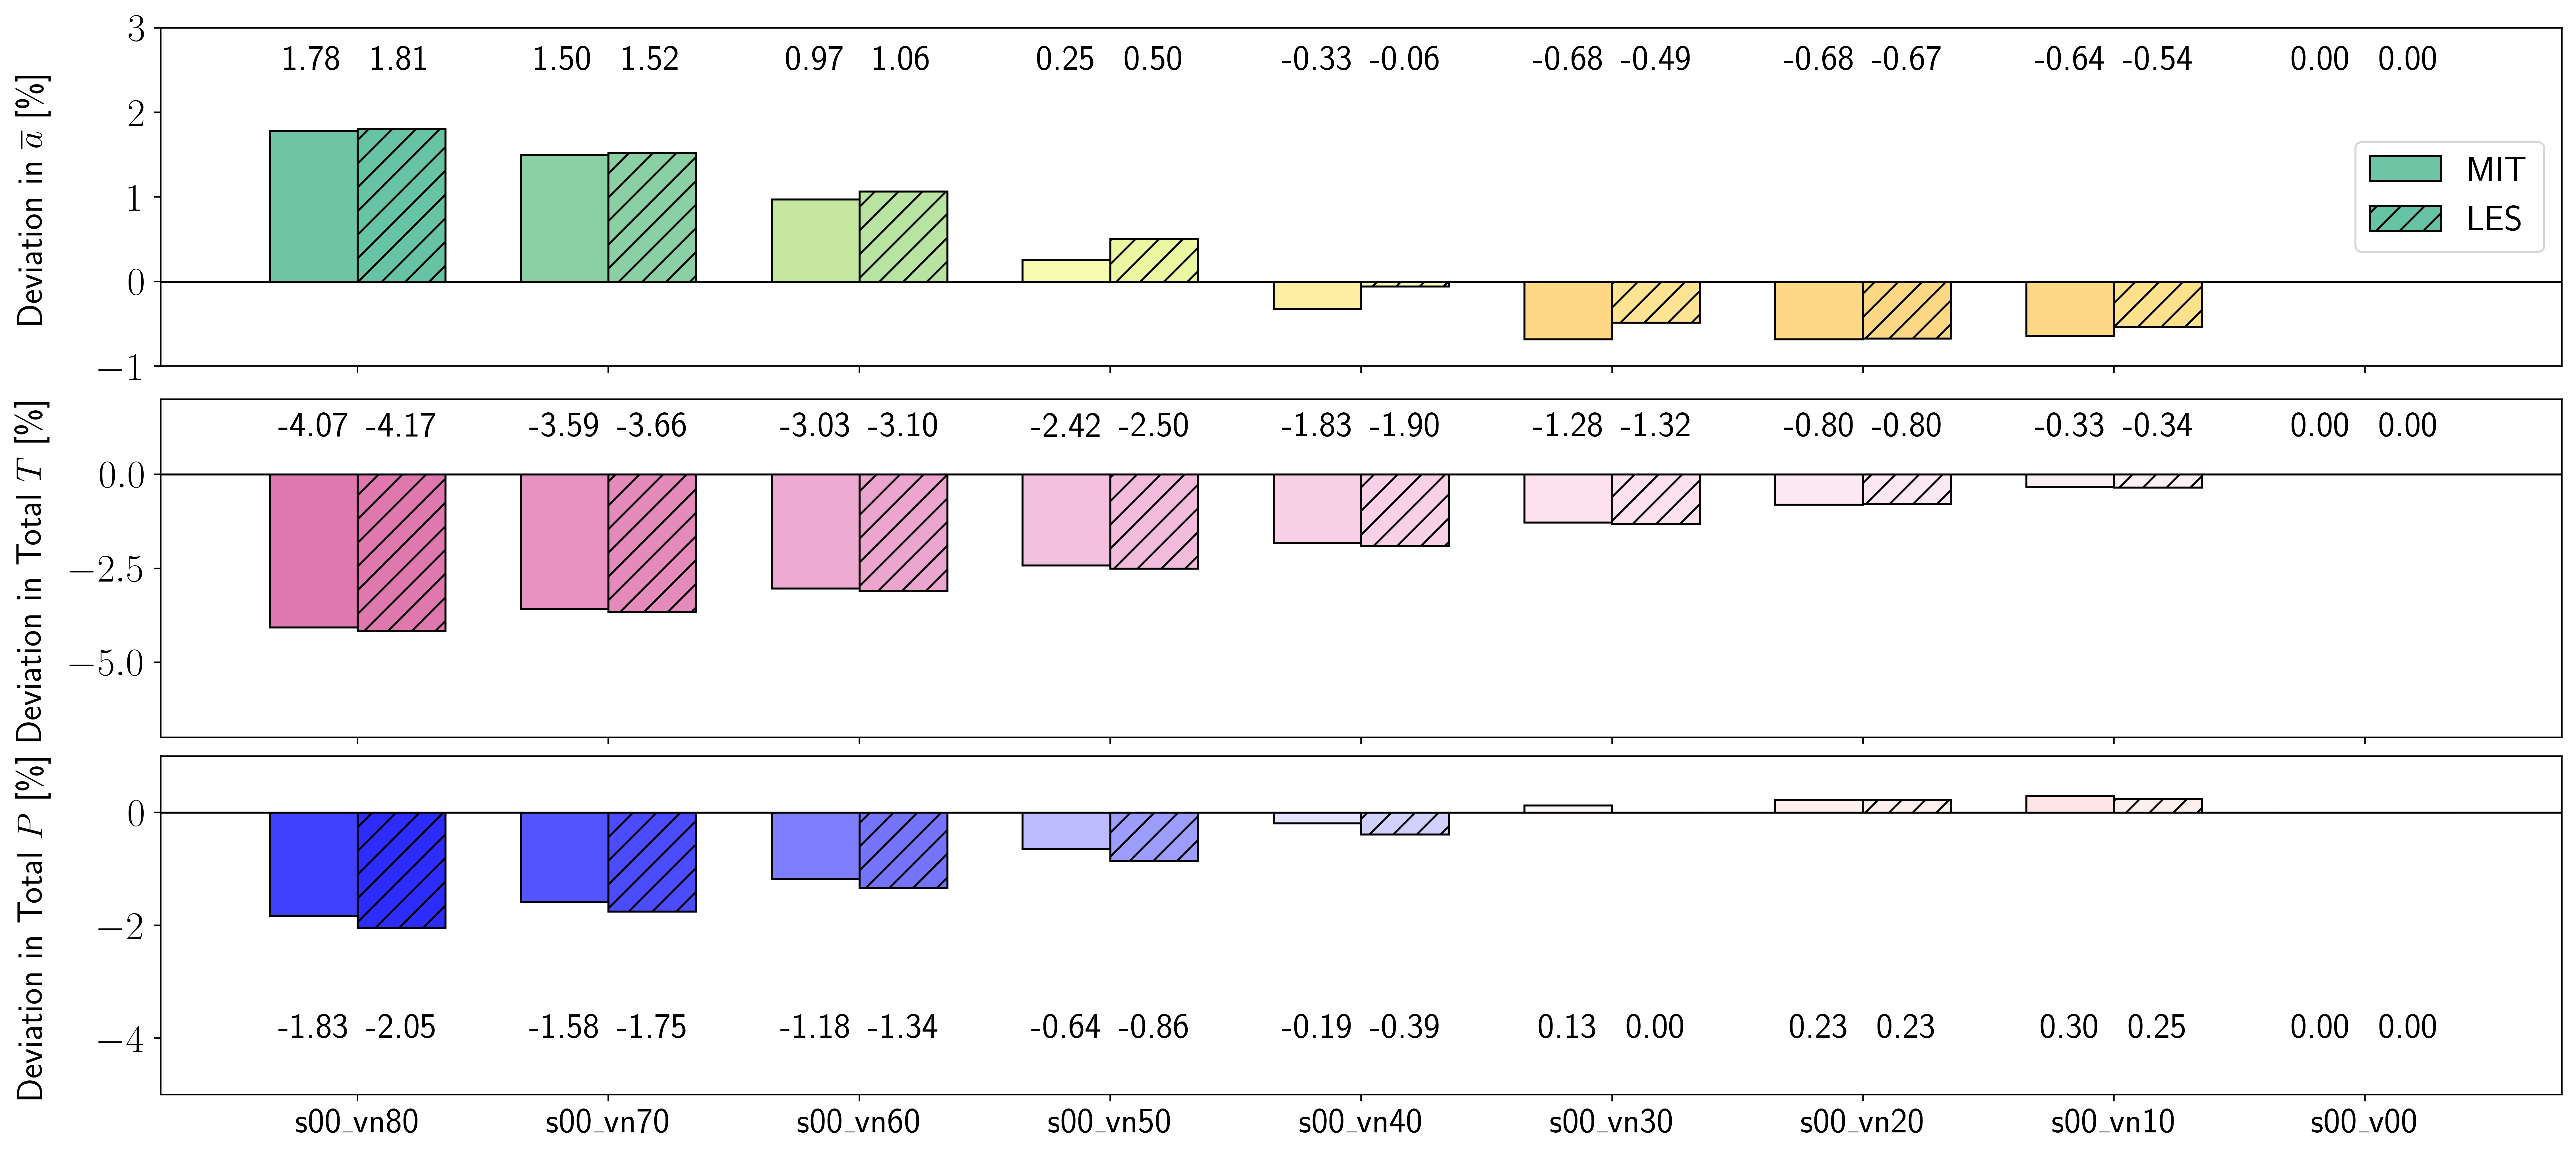

In [32]:
# Relative

width = 0.35
alpha = 1.0
fontsize = 18

n_levels = 100

pow_levels = plt.colormaps['seismic'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=-5, vmax=5)  # Normalize power to [0, 1]
wrf_pow_cmap = [pow_levels(int(norm(p) * (n_levels - 1))) for p in wrf_power_dev]  # Map power to discrete colors
mit_pow_cmap = [pow_levels(int(norm(p) * (n_levels - 1))) for p in mit_power_dev]  # Map power to discrete colors

thr_levels = plt.colormaps['PiYG'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=-7, vmax=7)  # Normalize power to [0, 1]
wrf_thr_cmap = [thr_levels(int(norm(t) * (n_levels - 1))) for t in wrf_thrust_dev]  # Map power to discrete colors
mit_thr_cmap = [thr_levels(int(norm(t) * (n_levels - 1))) for t in mit_thrust_dev]  # Map power to discrete colors

ind_levels = plt.colormaps['Spectral'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=-3, vmax=3)  # Normalize power to [0, 1]
wrf_ind_cmap = [ind_levels(int(norm(a) * (n_levels - 1))) for a in wrf_induction_dev]  # Map power to discrete colors
mit_ind_cmap = [ind_levels(int(norm(a) * (n_levels - 1))) for a in mit_induction_dev]  # Map power to discrete colors

ind = np.arange(len(new_names))

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, constrained_layout=True)

for a in ax:
    a.axhline(0, color='black', linestyle='solid', linewidth=1)

# Plotting
for count in range(len(new_names)):
    # --- Induction
    ax[0].bar(ind[count] - width/2, mit_induction_dev[count], width,
              color=mit_ind_cmap[count], edgecolor='black', alpha=alpha, label='MIT' if count == 0 else "")
    
    ax[0].bar(ind[count] + width/2, wrf_induction_dev[count], width,
              color=wrf_ind_cmap[count], edgecolor='black', alpha=alpha, hatch='//', label='LES' if count == 0 else "")
    
    ax[0].text(ind[count] - width/2, 2.5,
               f'{mit_induction_dev[count]:0.2f}%', ha='center', fontsize=fontsize)
    
    ax[0].text(ind[count] + width/2, 2.5,
               f'{wrf_induction_dev[count]:0.2f}%', ha='center', fontsize=fontsize)
    
    ax[0].set_ylabel(r'Deviation in $\overline{a}$ [\%]', fontsize=fontsize, labelpad=24)
    ax[0].set_ylim([-1,3])

    # --- Thrust
    ax[1].bar(ind[count] - width/2, mit_thrust_dev[count], width,
              color=mit_thr_cmap[count], edgecolor='black', alpha=alpha)
    
    ax[1].bar(ind[count] + width/2, wrf_thrust_dev[count], width,
              color=wrf_thr_cmap[count], edgecolor='black', alpha=alpha, hatch='//')
    
    ax[1].text(ind[count] - width/2, 1,
               f'{mit_thrust_dev[count]:0.2f}%', ha='center', fontsize=fontsize)
    
    ax[1].text(ind[count] + width/2, 1,
               f'{wrf_thrust_dev[count]:0.2f}%', ha='center', fontsize=fontsize)
    
    ax[1].set_ylabel(r'Deviation in Total $T$ [\%]', fontsize=fontsize, labelpad=10)
    ax[1].set_ylim([-7,2])

    # --- Power
    ax[2].bar(ind[count] - width/2, mit_power_dev[count], width,
              color=mit_pow_cmap[count], edgecolor='black', alpha=alpha)
    
    ax[2].bar(ind[count] + width/2, wrf_power_dev[count], width,
              color=wrf_pow_cmap[count], edgecolor='black', alpha=alpha, hatch='//')
    
    ax[2].text(ind[count] - width/2, -4,
               f'{mit_power_dev[count]:0.2f}%', ha='center', fontsize=fontsize)
    
    ax[2].text(ind[count] + width/2, -4,
               f'{wrf_power_dev[count]:0.2f}%', ha='center', fontsize=fontsize)
    
    ax[2].set_ylabel(r'Deviation in Total $P$ [\%]', fontsize=fontsize, labelpad=24)
    ax[2].set_ylim([-5,1])

# Final formatting
ax[2].set_xticks(ind)
ax[2].set_xticklabels(new_names, fontsize=fontsize)
ax[2].tick_params(axis='x', rotation=0)

# Add legend for MIT vs. WRF
ax[0].legend(fontsize=fontsize, loc='center right')

plt.show()


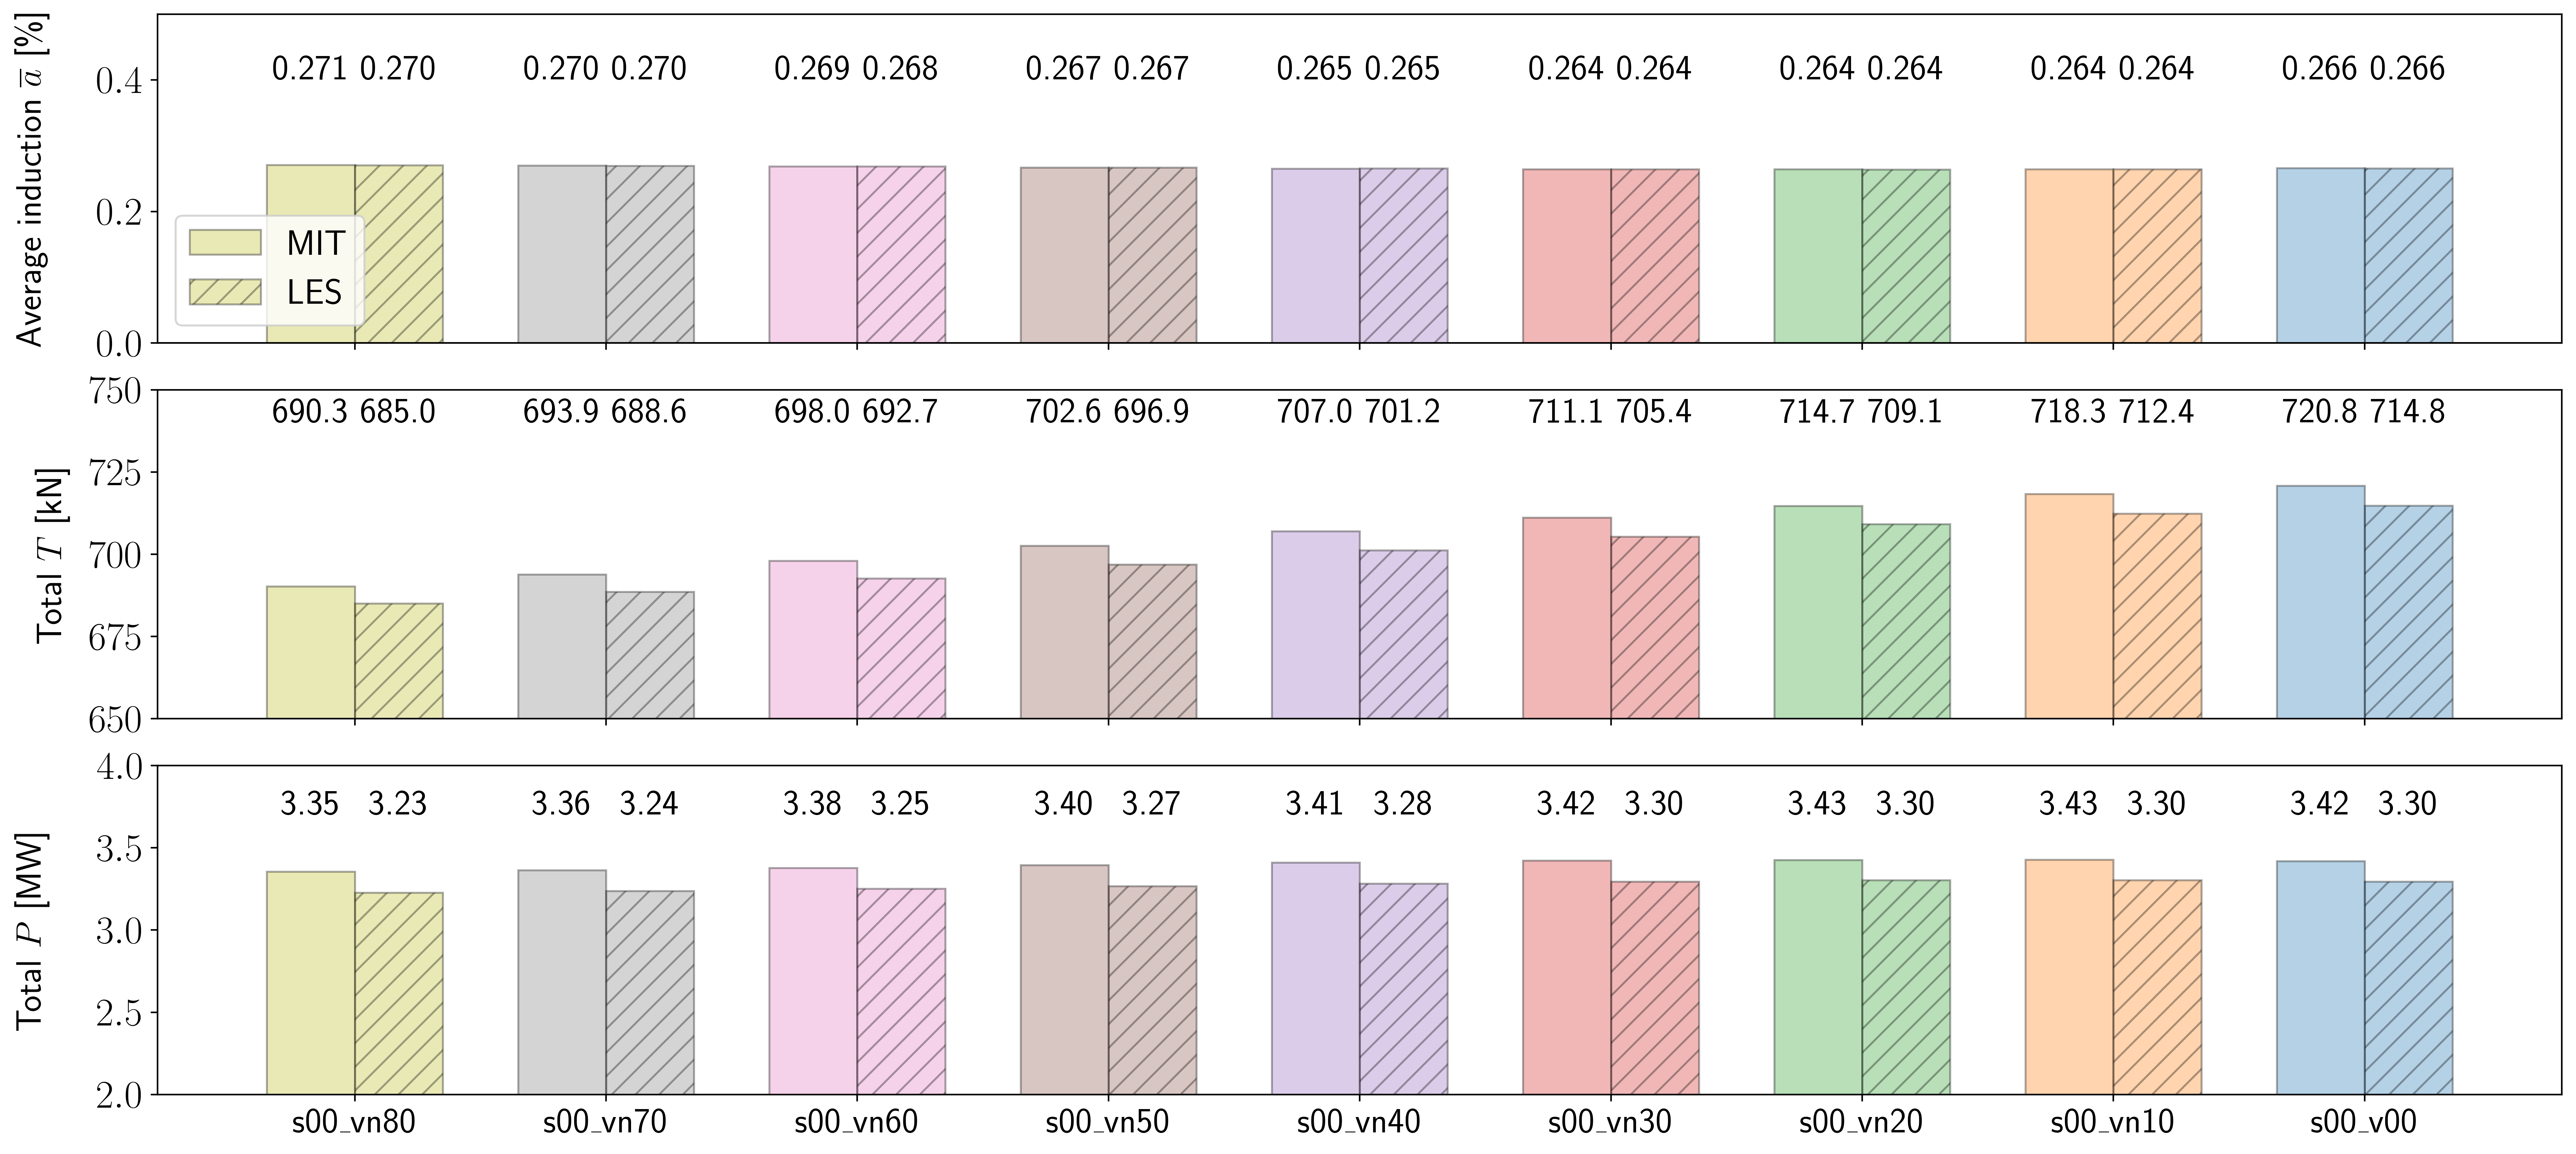

In [33]:
# Dimensional

width = 0.35
alpha = 1/3
fontsize = 18

full_colors = colors[::-1]

ind = np.arange(len(new_names))

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, constrained_layout=True)

for a in ax:
    a.axhline(0, color='black', linestyle='solid', linewidth=1)

# Plotting
for count in range(len(new_names)):
    # --- Induction

    ax[0].bar(ind[count] - width/2, mit_ind[count], width,
              color=full_colors[count], edgecolor='black', alpha=alpha, label='MIT' if count == 0 else "")
    
    ax[0].bar(ind[count] + width/2, wrf_ind_ss[count], width,
              color=full_colors[count], edgecolor='black', alpha=alpha, hatch='//', label='LES' if count == 0 else "")
    
    ax[0].text(ind[count] - width/2, 0.4,
               f'{mit_ind[count]:0.3f}%', ha='center', fontsize=fontsize)
    
    ax[0].text(ind[count] + width/2, 0.4,
               f'{wrf_ind_ss[count]:0.3f}%', ha='center', fontsize=fontsize)
    
    ax[0].set_ylabel(r'Average induction $\overline{a}$ [\%]', fontsize=fontsize, labelpad=24)
    ax[0].set_ylim([0, 0.5])

    # --- Thrust

    ax[1].bar(ind[count] - width/2, mit_thr[count], width,
              color=full_colors[count], edgecolor='black', alpha=alpha)
    
    ax[1].bar(ind[count] + width/2, wrf_thr_ss[count]/1e3, width,
              color=full_colors[count], edgecolor='black', alpha=alpha, hatch='//')
    
    ax[1].text(ind[count] - width/2, 740,
               f'{mit_thr[count]:0.1f}%', ha='center', fontsize=fontsize)
    
    ax[1].text(ind[count] + width/2, 740,
               f'{wrf_thr_ss[count]/1e3:0.1f}%', ha='center', fontsize=fontsize)
    
    ax[1].set_ylabel(r'Total $T$ [kN]', fontsize=fontsize, labelpad=10)
    ax[1].set_ylim([650, 750])

    # --- Power
    ax[2].bar(ind[count] - width/2, mit_pow[count], width,
              color=full_colors[count], edgecolor='black', alpha=alpha)
    
    ax[2].bar(ind[count] + width/2, wrf_pow_ss[count]/1e6, width,
              color=full_colors[count], edgecolor='black', alpha=alpha, hatch='//')
    
    ax[2].text(ind[count] - width/2, 3.7,
               f'{mit_pow[count]:0.2f}%', ha='center', fontsize=fontsize)
    
    ax[2].text(ind[count] + width/2, 3.7,
               f'{wrf_pow_ss[count]/1e6:0.2f}%', ha='center', fontsize=fontsize)
    
    ax[2].set_ylabel(r'Total $P$ [MW]', fontsize=fontsize, labelpad=24)
    ax[2].set_ylim([2, 4])

# Final formatting
ax[2].set_xticks(ind)
ax[2].set_xticklabels(new_names, fontsize=fontsize)
ax[2].tick_params(axis='x', rotation=0)

# Add legend for MIT vs. WRF
ax[0].legend(fontsize=fontsize, loc='lower left')

plt.show()


Text(0.5, 0, '$a$ [-]')

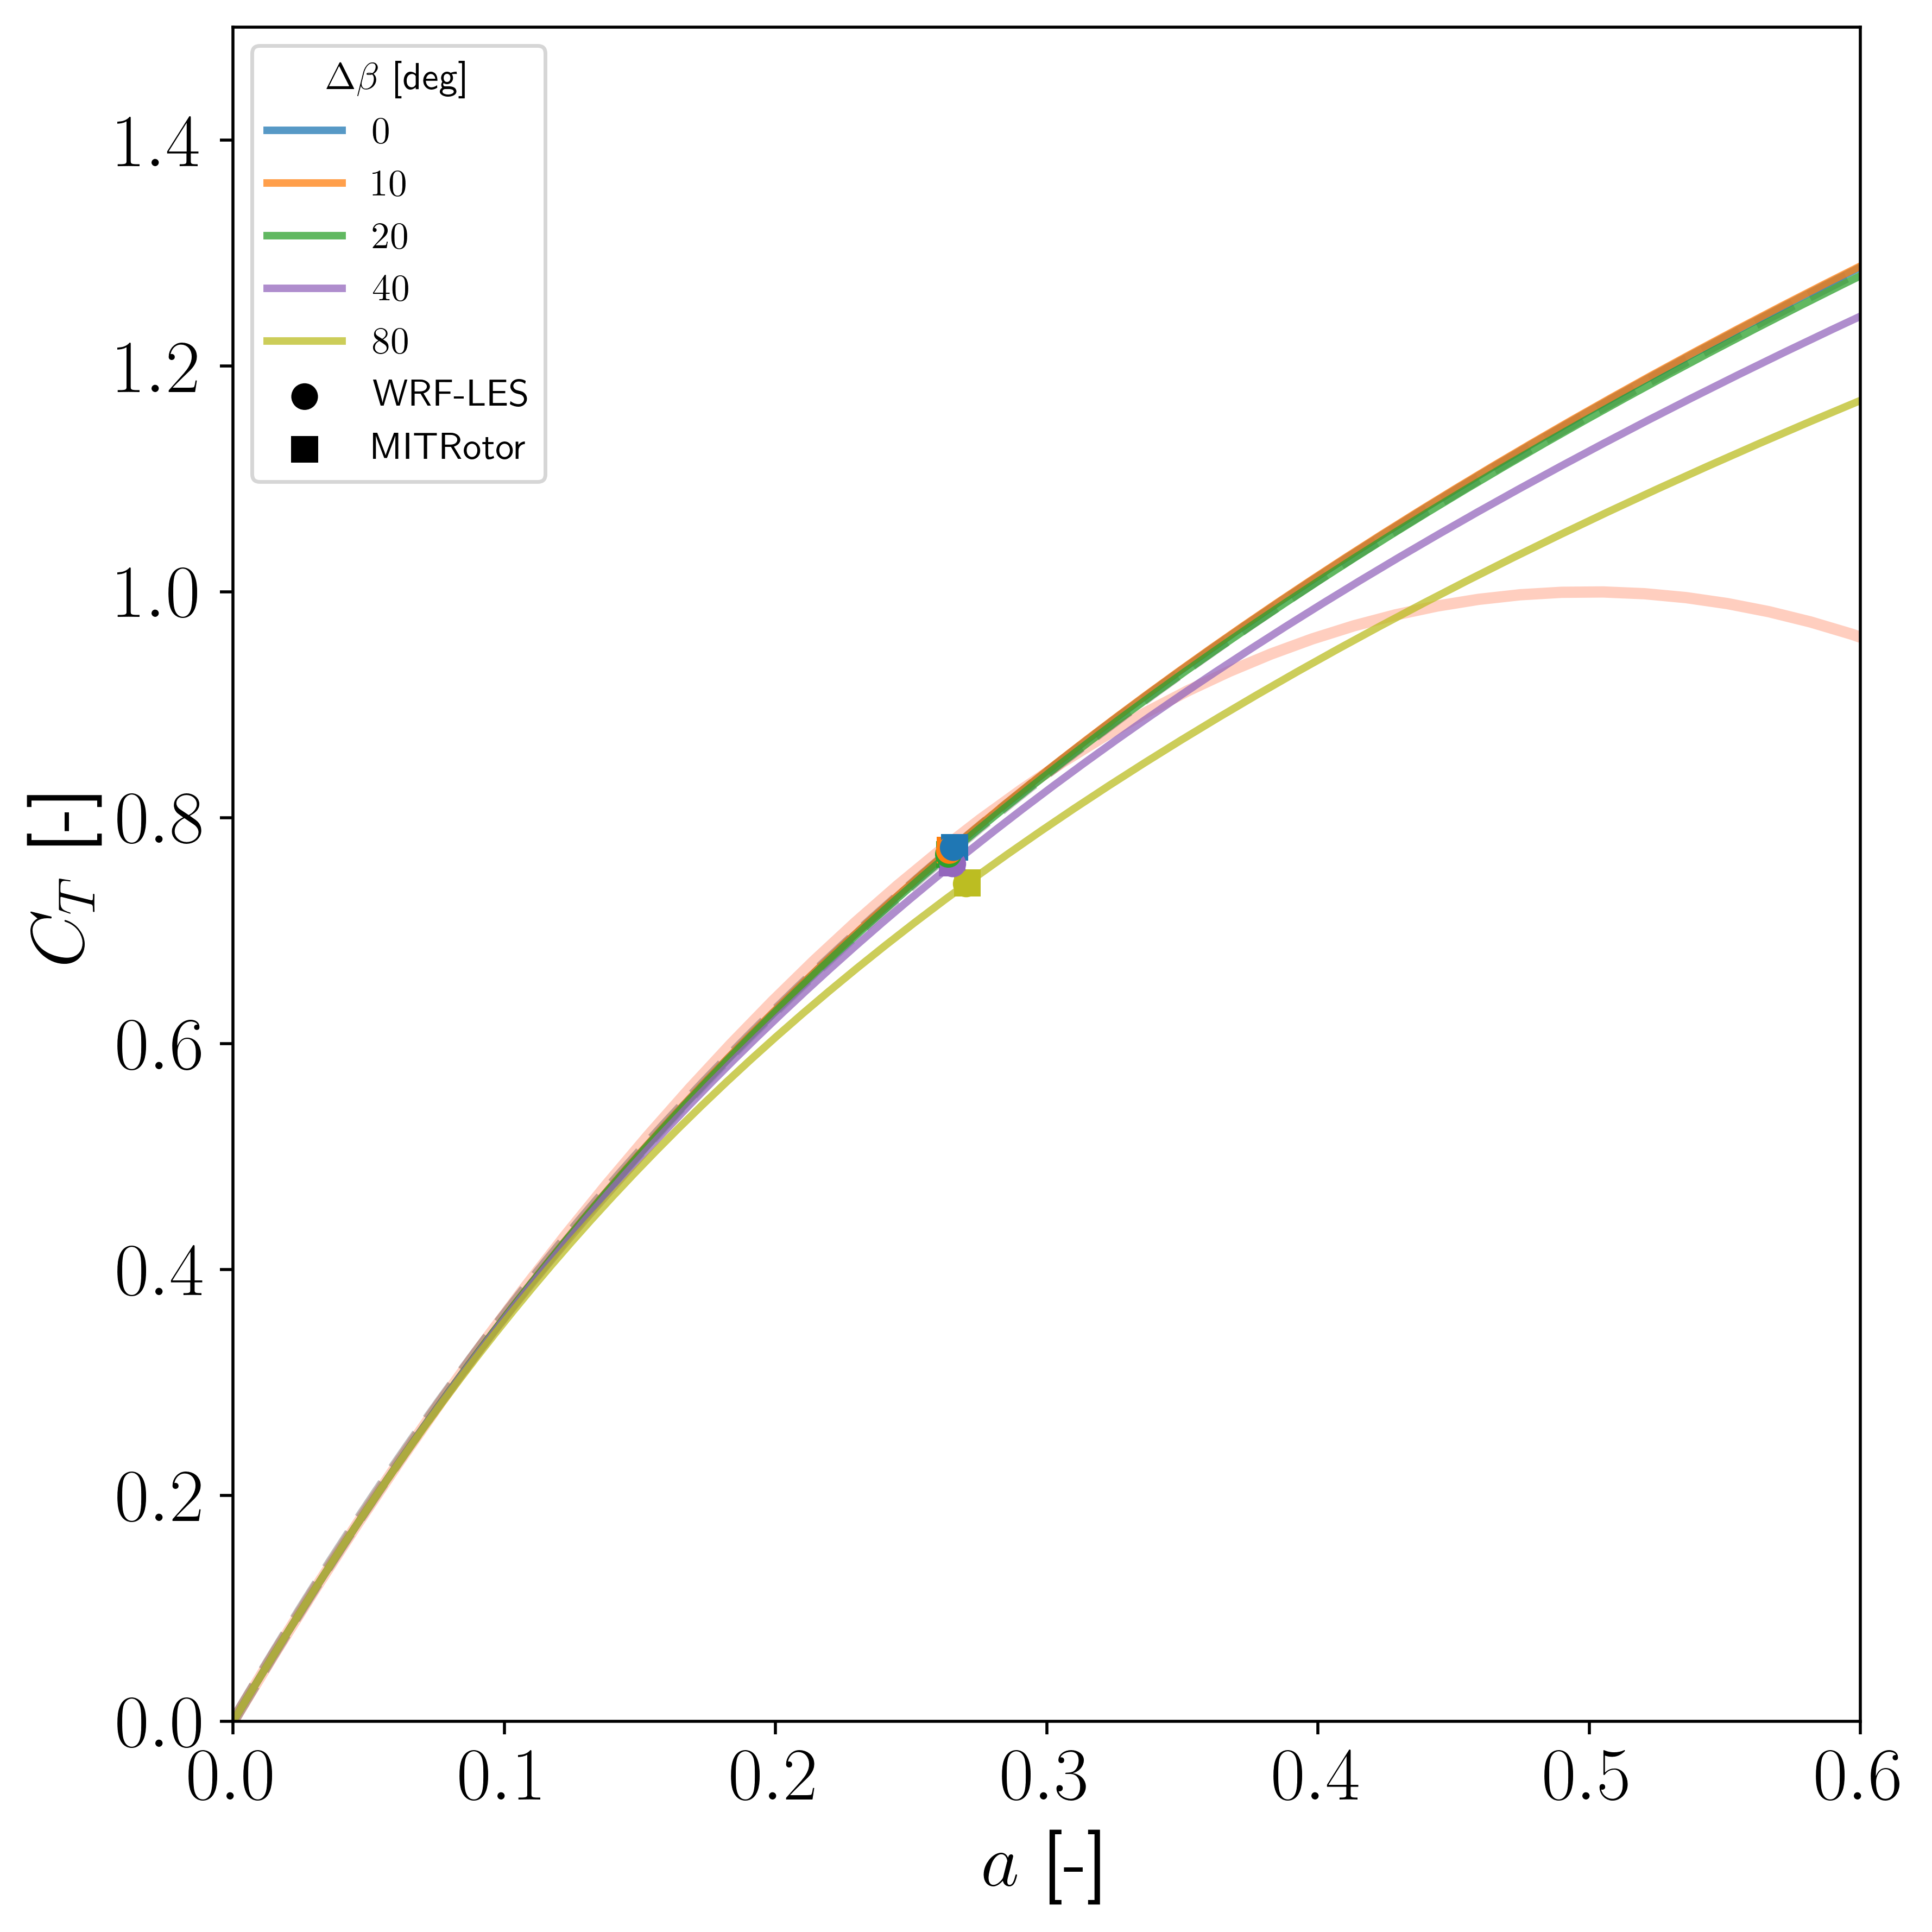

In [34]:
fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True,sharex=True, sharey=True)

a_mom  = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)
ax.plot(a_mom, ct_mom, '#ff3c00',linewidth=3,zorder=1,alpha=0.25)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
ax.plot(a_mad, ct_mad, 'k--',linewidth=3,zorder=2,alpha=0.25)

ax.plot(y_fit_v00, x_fit_v00, color=colors[0],linewidth=2,zorder=2,alpha=0.75,label='$0$')
ax.plot(y_fit_v10, x_fit_v10, color=colors[1],linewidth=2,zorder=2,alpha=0.75,label='$10$')
ax.plot(y_fit_v20, x_fit_v20, color=colors[2],linewidth=2,zorder=2,alpha=0.75,label='$20$')
ax.plot(y_fit_v40, x_fit_v40, color=colors[4],linewidth=2,zorder=2,alpha=0.75,label='$40$')
ax.plot(y_fit_v80, x_fit_v80, color=colors[8],linewidth=2,zorder=2,alpha=0.75,label='$80$')

mesh = ax.scatter(mit_ind[0], mit_cot[0], s=50, marker='s', edgecolor='none',color=colors[8],zorder=3)
mesh = ax.scatter(mit_ind[4], mit_cot[4], s=50, marker='s', edgecolor='none',color=colors[4],zorder=3)
mesh = ax.scatter(mit_ind[6], mit_cot[6], s=50, marker='s', edgecolor='none',color=colors[2],zorder=3)
mesh = ax.scatter(mit_ind[7], mit_cot[7], s=50, marker='s', edgecolor='none',color=colors[1],zorder=3)
mesh = ax.scatter(mit_ind[8], mit_cot[8], s=50, marker='s', edgecolor='none',color=colors[0],zorder=3)

mesh = ax.scatter(wrf_ind_ss[0], wrf_cot_ss[0], s=50, edgecolor='none',color=colors[8],zorder=3)
mesh = ax.scatter(wrf_ind_ss[4], wrf_cot_ss[4], s=50, edgecolor='none',color=colors[4],zorder=3)
mesh = ax.scatter(wrf_ind_ss[6], wrf_cot_ss[6], s=50, edgecolor='none',color=colors[2],zorder=3)
mesh = ax.scatter(wrf_ind_ss[7], wrf_cot_ss[7], s=50, edgecolor='none',color=colors[1],zorder=3)
mesh = ax.scatter(wrf_ind_ss[8], wrf_cot_ss[8], s=50, edgecolor='none',color=colors[0],zorder=3)

mesh = ax.scatter(-5, -5, s=50, edgecolor='none',color='k',zorder=3,label='WRF-LES')
mesh = ax.scatter(-5, -5, s=50, marker='s', edgecolor='none',color='k',zorder=3,label='MITRotor')

ax.legend(title='$\Delta \\beta$ [deg]')

ax.set_xlim([0,0.6])
ax.set_ylim([0,1.5])

# ax.set_xlim([0.25,0.275])
# ax.set_ylim([0.73,0.785])

ax.set_ylabel('$C_T$ [-]', fontsize=20)
ax.set_xlabel('$a$ [-]', fontsize=20)

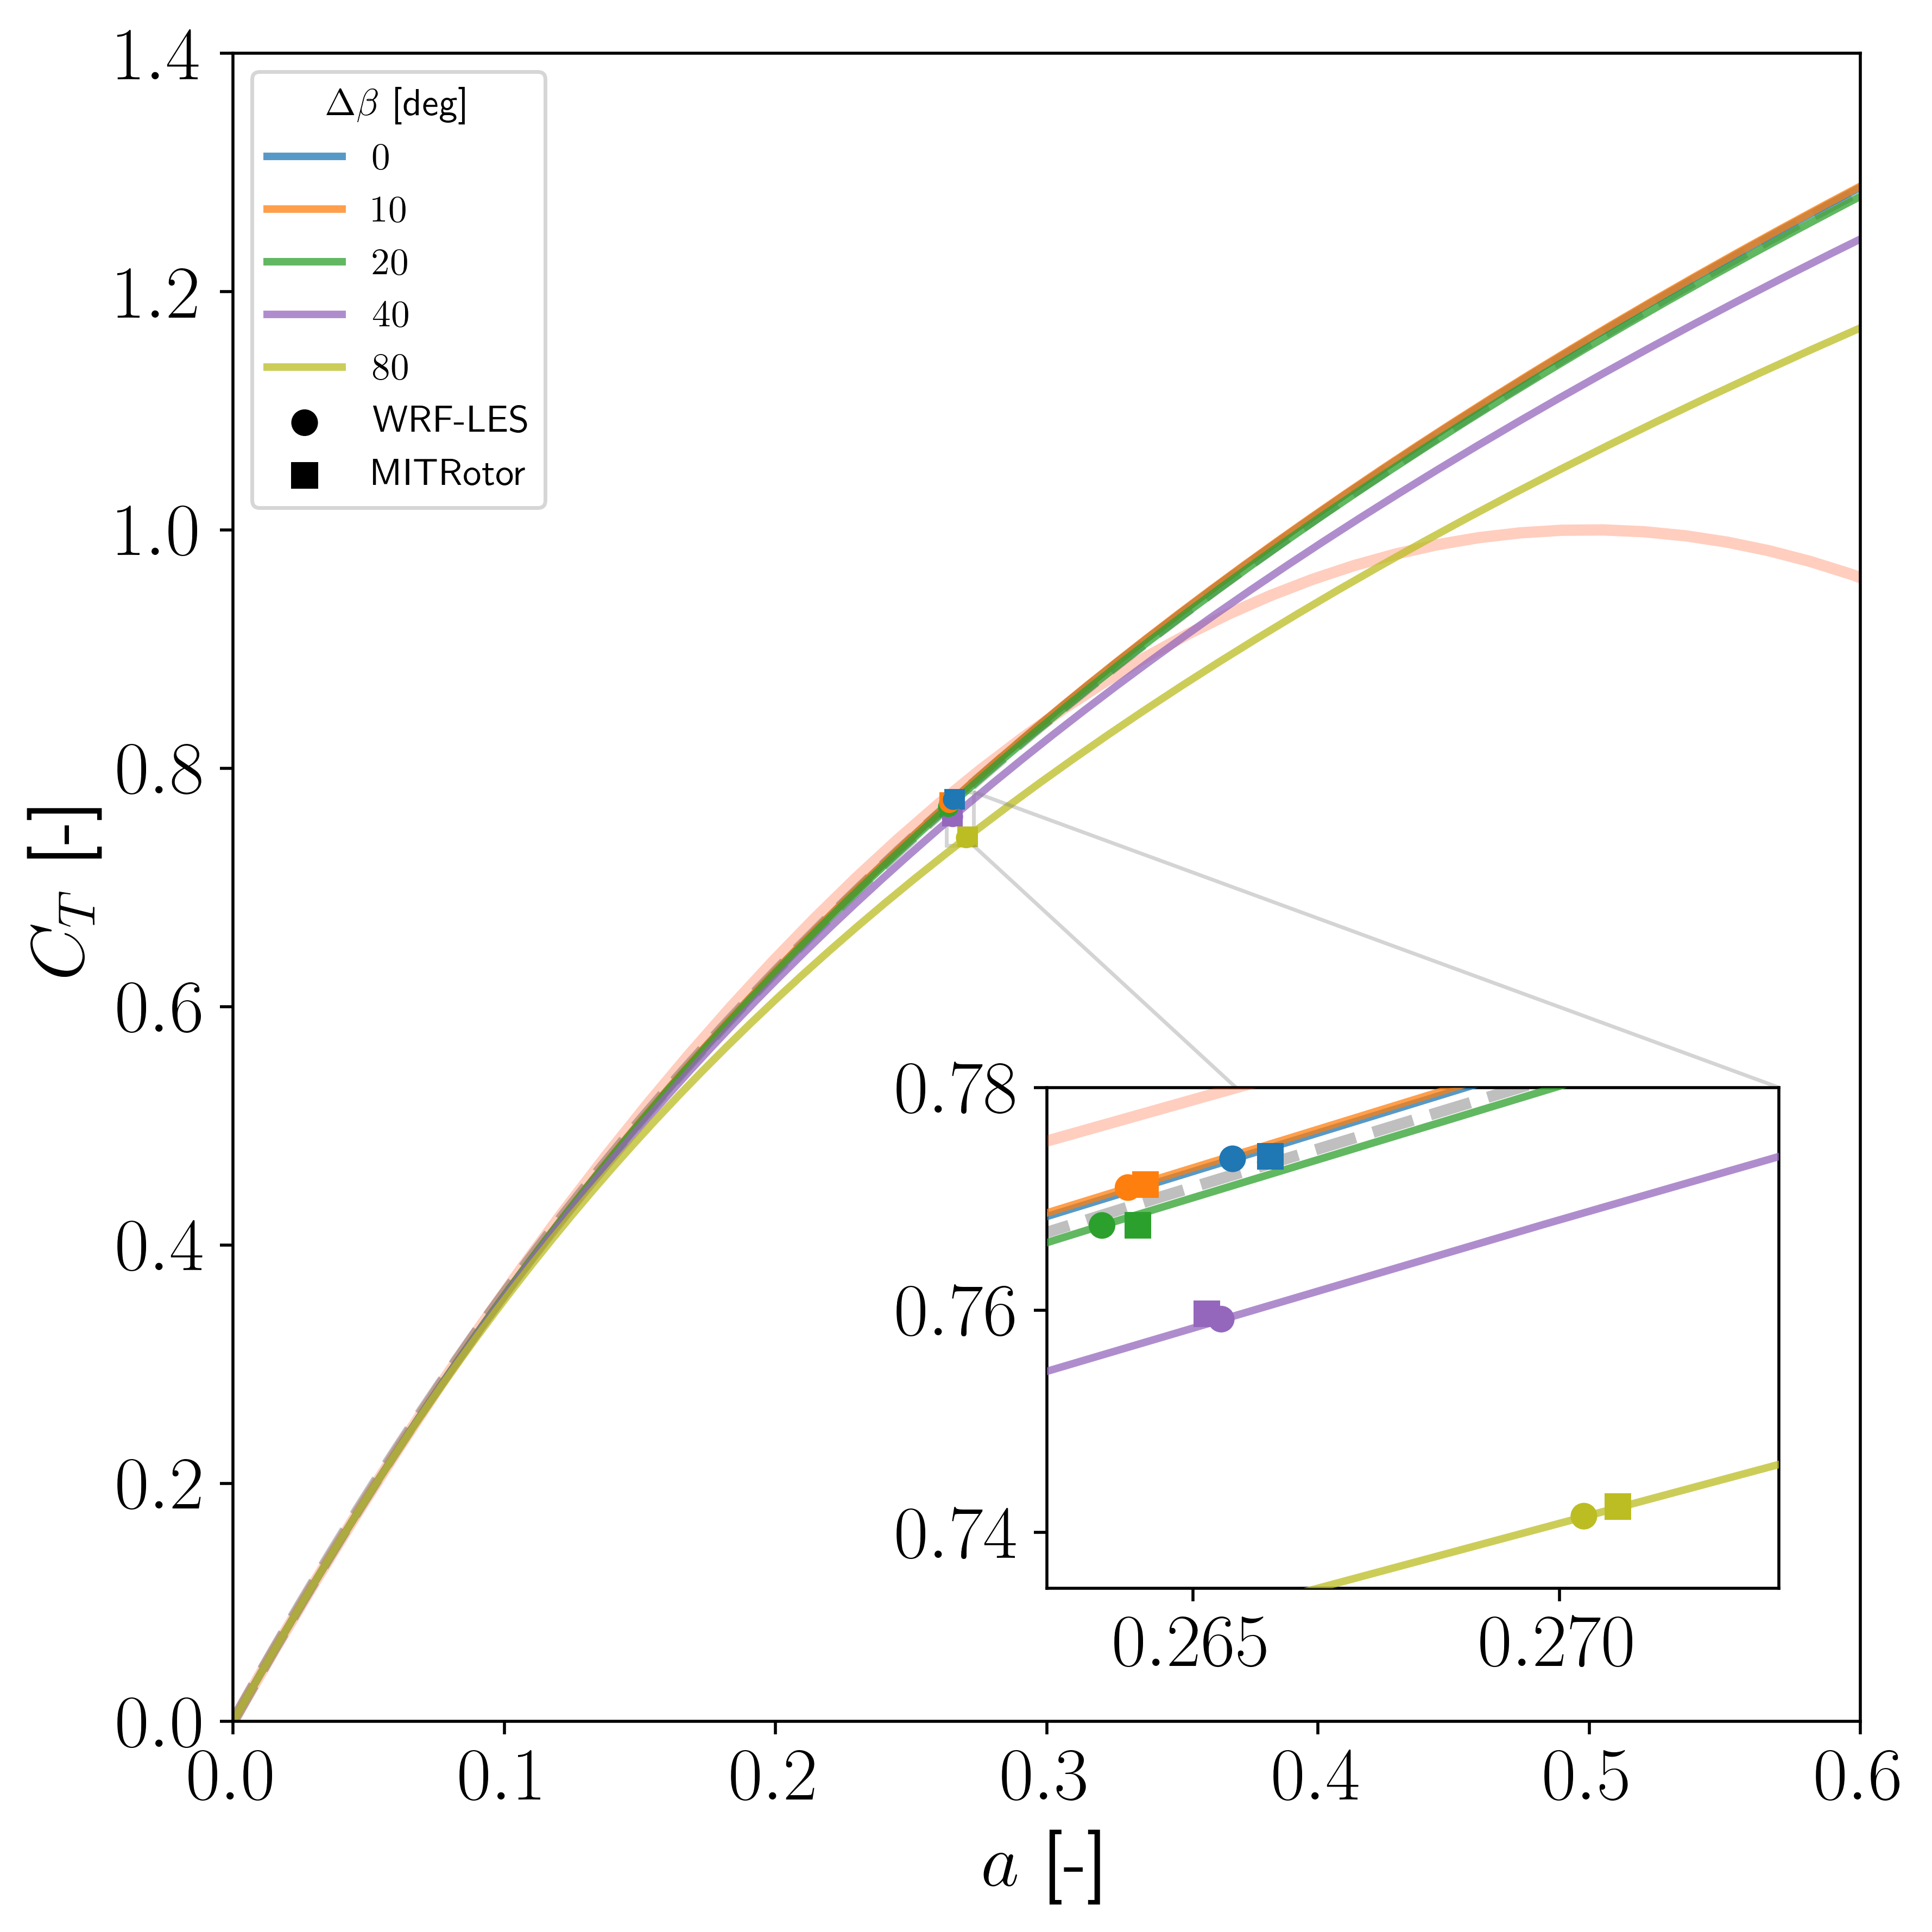

In [45]:
# Create the main figure and axis
fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)

a_mom  = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)
ax.plot(a_mom, ct_mom, '#ff3c00',linewidth=3,zorder=1,alpha=0.25)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
ax.plot(a_mad, ct_mad, 'k--',linewidth=3,zorder=2,alpha=0.25)

ax.plot(y_fit_v00, x_fit_v00, color=colors[0],linewidth=2,zorder=2,alpha=0.75,label='$0$')
ax.plot(y_fit_v10, x_fit_v10, color=colors[1],linewidth=2,zorder=2,alpha=0.75,label='$10$')
ax.plot(y_fit_v20, x_fit_v20, color=colors[2],linewidth=2,zorder=2,alpha=0.75,label='$20$')
ax.plot(y_fit_v40, x_fit_v40, color=colors[4],linewidth=2,zorder=2,alpha=0.75,label='$40$')
ax.plot(y_fit_v80, x_fit_v80, color=colors[8],linewidth=2,zorder=2,alpha=0.75,label='$80$')

mesh = ax.scatter(mit_ind[0], mit_cot[0], s=30, marker='s', edgecolor='none',color=colors[8],zorder=3)
mesh = ax.scatter(mit_ind[4], mit_cot[4], s=30, marker='s', edgecolor='none',color=colors[4],zorder=3)
mesh = ax.scatter(mit_ind[6], mit_cot[6], s=30, marker='s', edgecolor='none',color=colors[2],zorder=3)
mesh = ax.scatter(mit_ind[7], mit_cot[7], s=30, marker='s', edgecolor='none',color=colors[1],zorder=3)
mesh = ax.scatter(mit_ind[8], mit_cot[8], s=30, marker='s', edgecolor='none',color=colors[0],zorder=3)

mesh = ax.scatter(wrf_ind_ss[0], wrf_cot_ss[0], s=30, edgecolor='none',color=colors[8],zorder=3)
mesh = ax.scatter(wrf_ind_ss[4], wrf_cot_ss[4], s=30, edgecolor='none',color=colors[4],zorder=3)
mesh = ax.scatter(wrf_ind_ss[6], wrf_cot_ss[6], s=30, edgecolor='none',color=colors[2],zorder=3)
mesh = ax.scatter(wrf_ind_ss[7], wrf_cot_ss[7], s=30, edgecolor='none',color=colors[1],zorder=3)
mesh = ax.scatter(wrf_ind_ss[8], wrf_cot_ss[8], s=30, edgecolor='none',color=colors[0],zorder=3)

mesh = ax.scatter(-5, -5, s=50, edgecolor='none',color='k',zorder=3,label='WRF-LES')
mesh = ax.scatter(-5, -5, s=50, marker='s', edgecolor='none',color='k',zorder=3,label='MITRotor')

ax.legend(title='$\Delta \\beta$ [deg]')

# === Add inset axes ===
# Example: Zoom into a cluster near a=0.32, CT=0.7

inset_ax = ax.inset_axes(
   [0.5, 0.08, 0.45, 0.3],  # [x, y, width, height] w.r.t. axes
    xlim=[0.263, 0.273], ylim=[0.735, 0.78] # sets viewport & tells relation to main axes
    # xticklabels=[], yticklabels=[]
)

# # Plot the same data inside the inset
inset_ax.plot(a_mom, ct_mom, '#ff3c00', linewidth=3, alpha=0.25,zorder=3)
inset_ax.plot(a_mad, ct_mad, 'k--', linewidth=3, alpha=0.25,zorder=3)

# # Re-plot the fitted curves
inset_ax.plot(y_fit_v00, x_fit_v00, color=colors[0],linewidth=2,zorder=3,alpha=0.75)
inset_ax.plot(y_fit_v10, x_fit_v10, color=colors[1],linewidth=2,zorder=3,alpha=0.75)
inset_ax.plot(y_fit_v20, x_fit_v20, color=colors[2],linewidth=2,zorder=3,alpha=0.75)
inset_ax.plot(y_fit_v40, x_fit_v40, color=colors[4],linewidth=2,zorder=3,alpha=0.75)
inset_ax.plot(y_fit_v80, x_fit_v80, color=colors[8],linewidth=2,zorder=3,alpha=0.75)

import matplotlib.patches as patches

rect = patches.Rectangle((0.2, 0.6), 0.2, 0.2, facecolor='white', edgecolor='k',zorder=2)
inset_ax.add_patch(rect)

inset_ax.scatter(mit_ind[0], mit_cot[0], s=50, marker='s', edgecolor='none',color=colors[8],zorder=3)
inset_ax.scatter(mit_ind[4], mit_cot[4], s=50, marker='s', edgecolor='none',color=colors[4],zorder=3)
inset_ax.scatter(mit_ind[6], mit_cot[6], s=50, marker='s', edgecolor='none',color=colors[2],zorder=3)
inset_ax.scatter(mit_ind[7], mit_cot[7], s=50, marker='s', edgecolor='none',color=colors[1],zorder=3)
inset_ax.scatter(mit_ind[8], mit_cot[8], s=50, marker='s', edgecolor='none',color=colors[0],zorder=3)

inset_ax.scatter(wrf_ind_ss[0], wrf_cot_ss[0], s=50, edgecolor='none',color=colors[8],zorder=3)
inset_ax.scatter(wrf_ind_ss[4], wrf_cot_ss[4], s=50, edgecolor='none',color=colors[4],zorder=3)
inset_ax.scatter(wrf_ind_ss[6], wrf_cot_ss[6], s=50, edgecolor='none',color=colors[2],zorder=3)
inset_ax.scatter(wrf_ind_ss[7], wrf_cot_ss[7], s=50, edgecolor='none',color=colors[1],zorder=3)
inset_ax.scatter(wrf_ind_ss[8], wrf_cot_ss[8], s=50, edgecolor='none',color=colors[0],zorder=3)

# Add a rectangle on the main plot showing the zoomed region
mark_inset(ax, inset_ax, loc1=1, loc2=4, fc="none", ec="0.5",zorder=1,alpha=1/3)

ax.set_xlim([0,0.6])
ax.set_ylim([0,1.4])

ax.set_ylabel('$C_T$ [-]', fontsize=20)
ax.set_xlabel('$a$ [-]', fontsize=20)

plt.show()

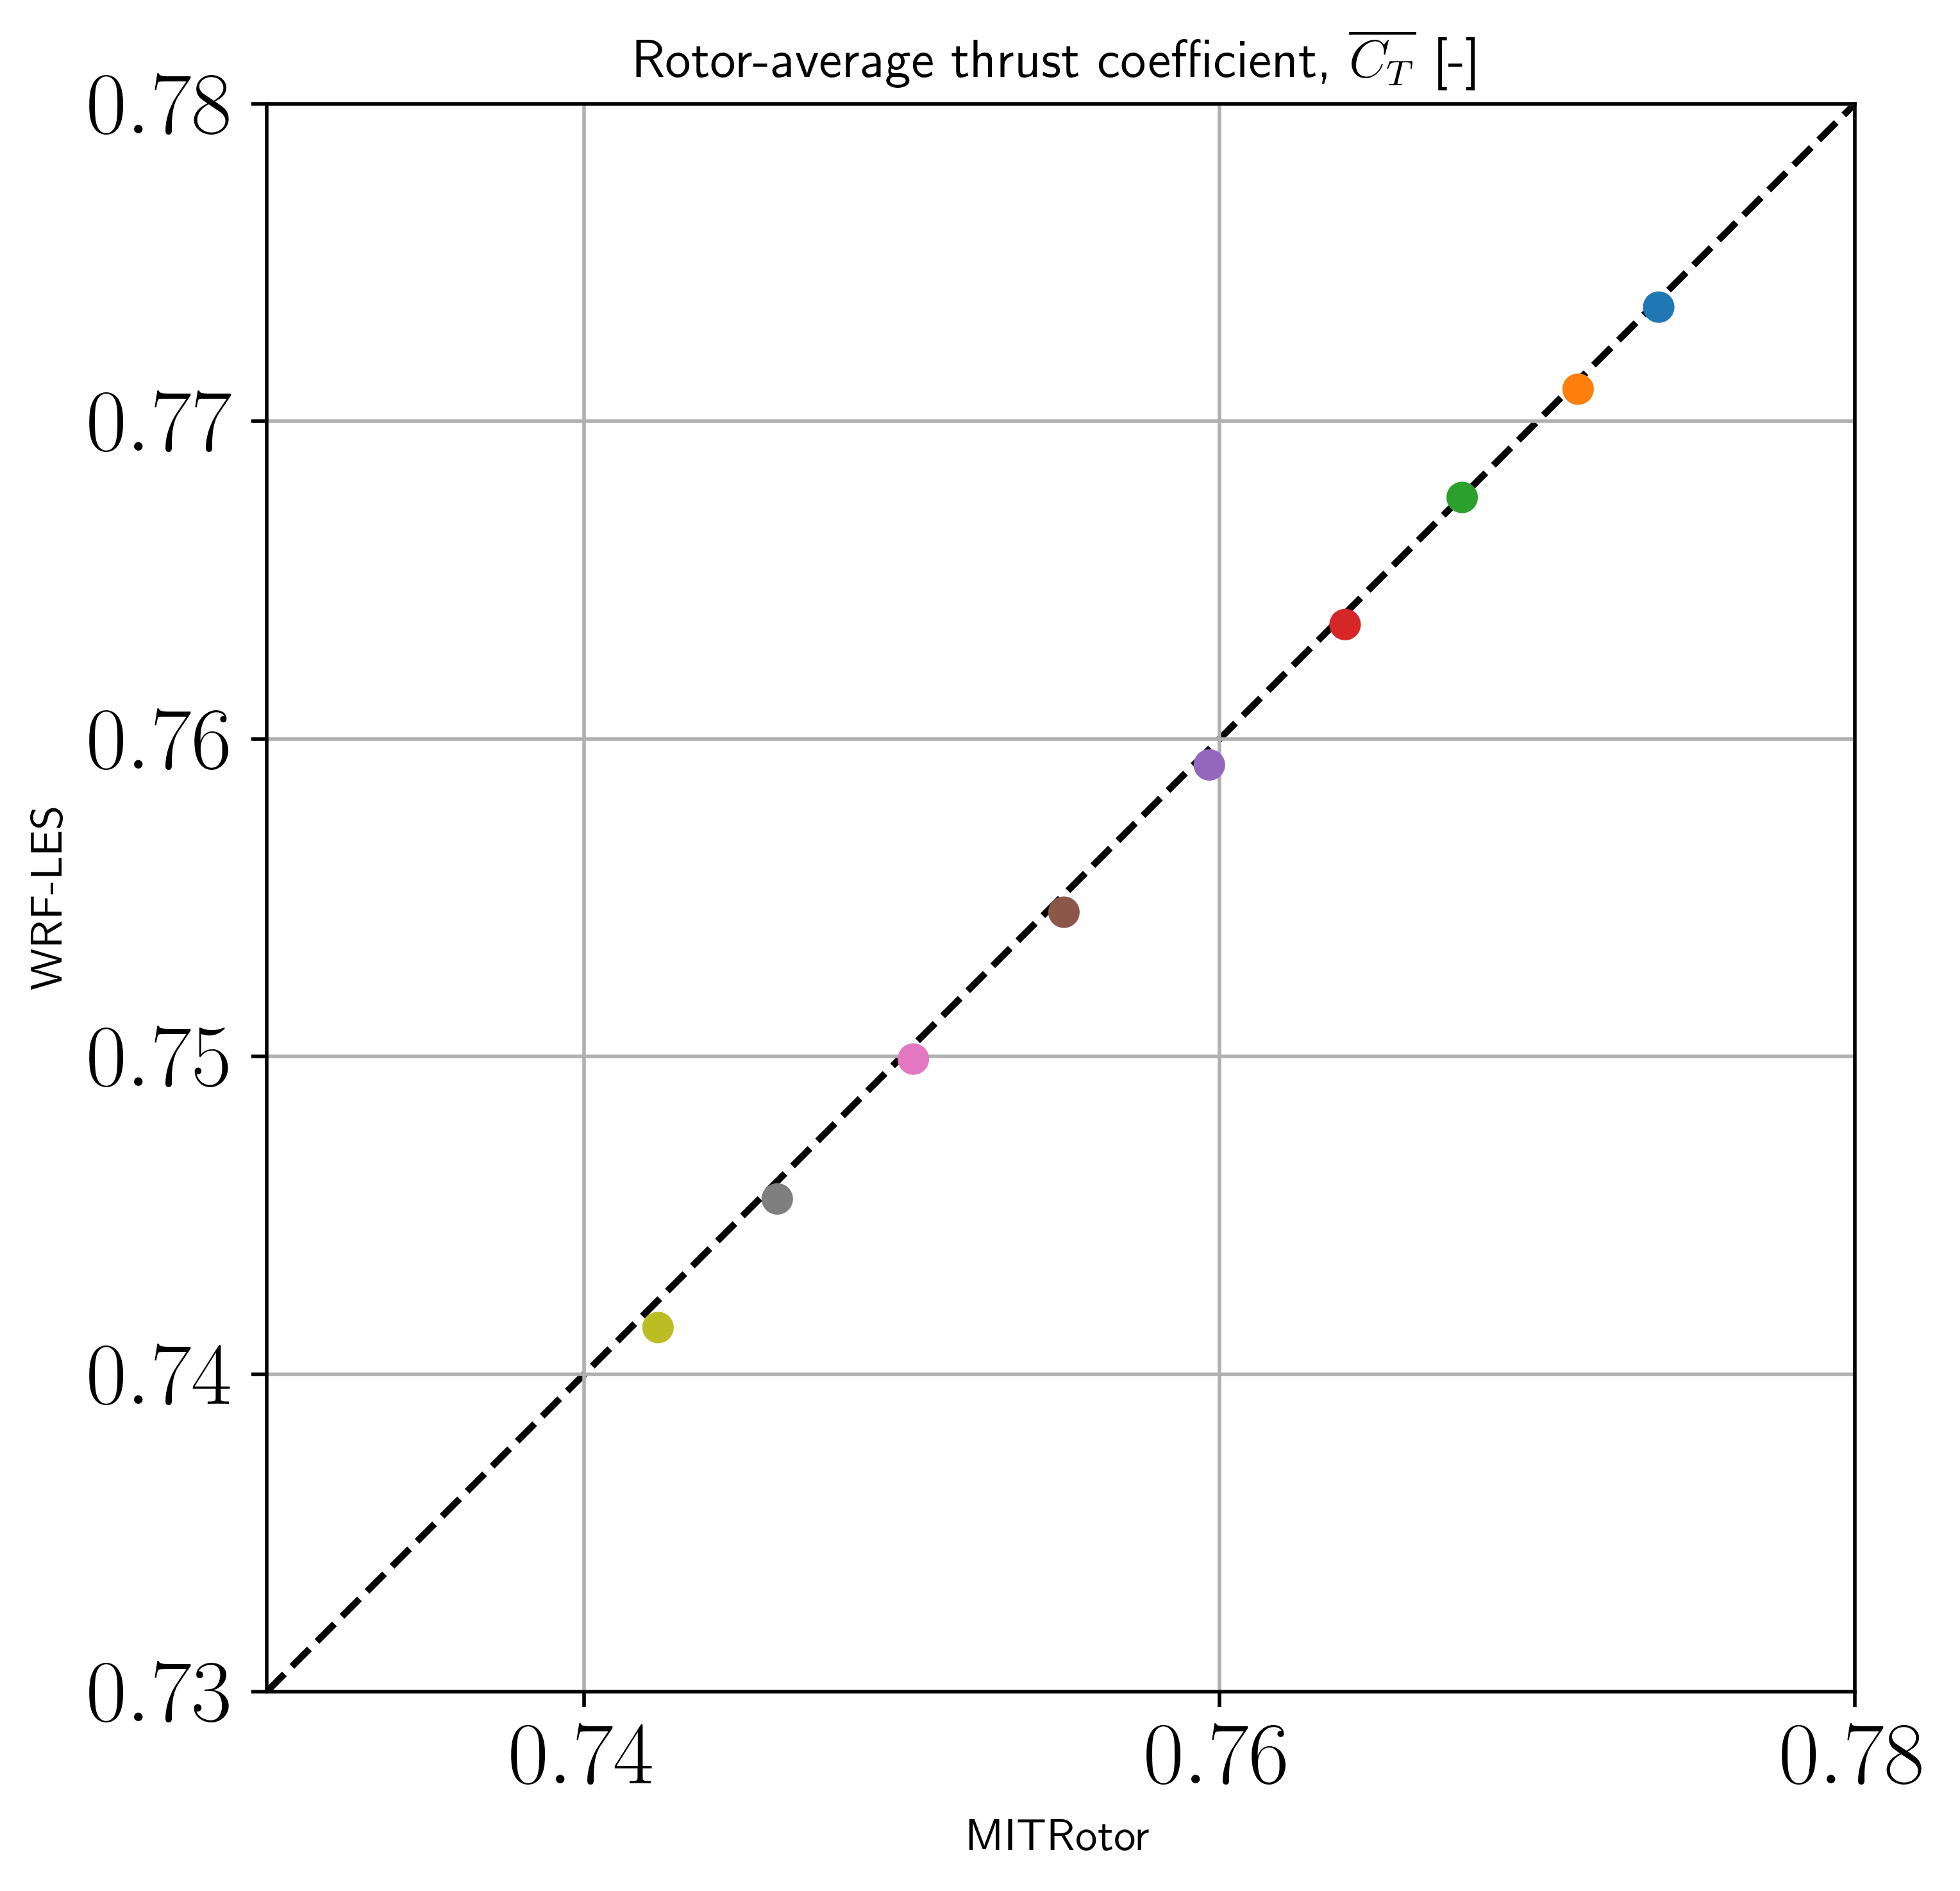

In [84]:
# Create plot
fig,ax = plt.subplots(figsize=(8, 6))
for i in range(len(mit_cot)):
    ax.scatter(mit_cot[i], wrf_cot_ss[i], s=50, edgecolor='none', color=full_colors[i], zorder = i+2)

ax.plot([0,3],[0,3],color='k',linestyle='--',zorder=1)

ax.set_xlim([0.73,0.78])
ax.set_ylim([0.73,0.78])
ax.set_aspect('equal')

plt.title(r"Rotor-average thrust coefficient, $\overline{C_T}$ [-]")
plt.xlabel("MITRotor")
plt.ylabel("WRF-LES")
plt.grid(True)
plt.tight_layout()
plt.show()

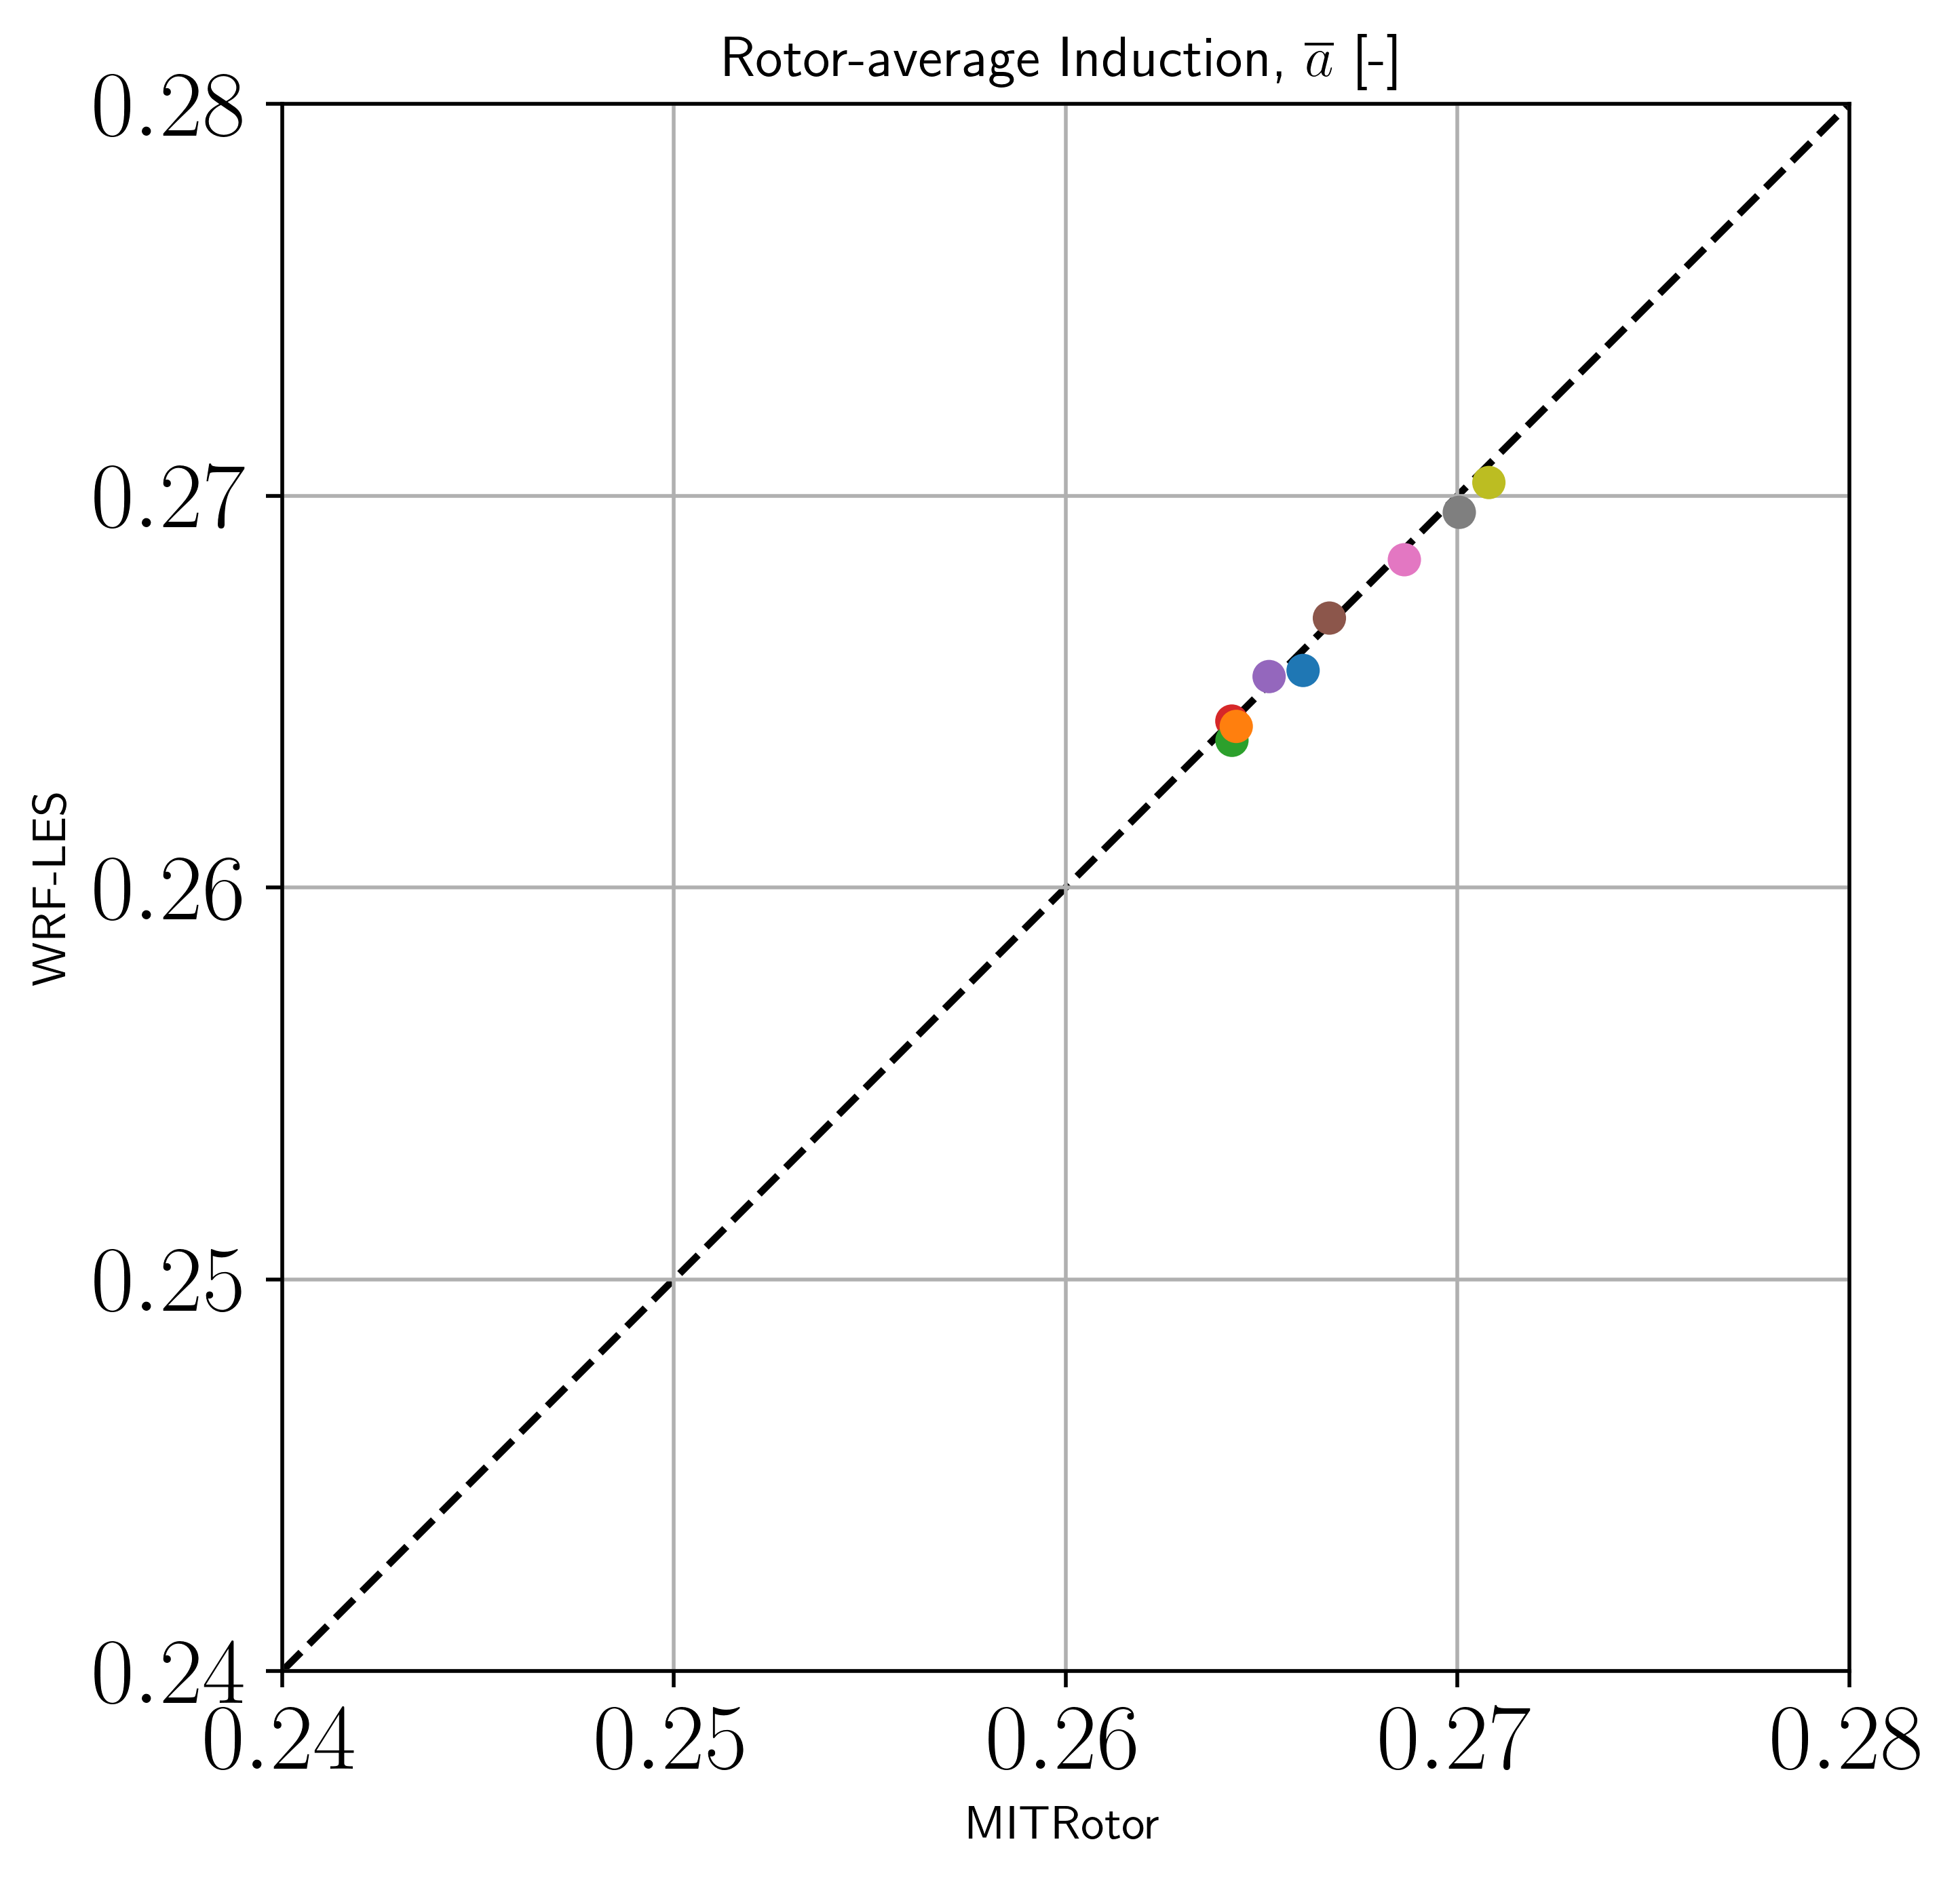

In [85]:
# Create plot
fig,ax = plt.subplots(figsize=(8, 6))
for i in range(len(mit_ind)):
    ax.scatter(mit_ind[i], wrf_ind_ss[i], s=50, edgecolor='none', color=full_colors[i], zorder=i+2)

ax.plot([0,1],[0,1],color='k',linestyle='--',zorder=1)

ax.set_xlim([0.24,0.28])
ax.set_ylim([0.24,0.28])
ax.set_aspect('equal')

plt.title(r"Rotor-average Induction, $\overline{a}$ [-]")
plt.xlabel("MITRotor")
plt.ylabel("WRF-LES")
plt.grid(True)
# plt.tight_layout()
plt.show()

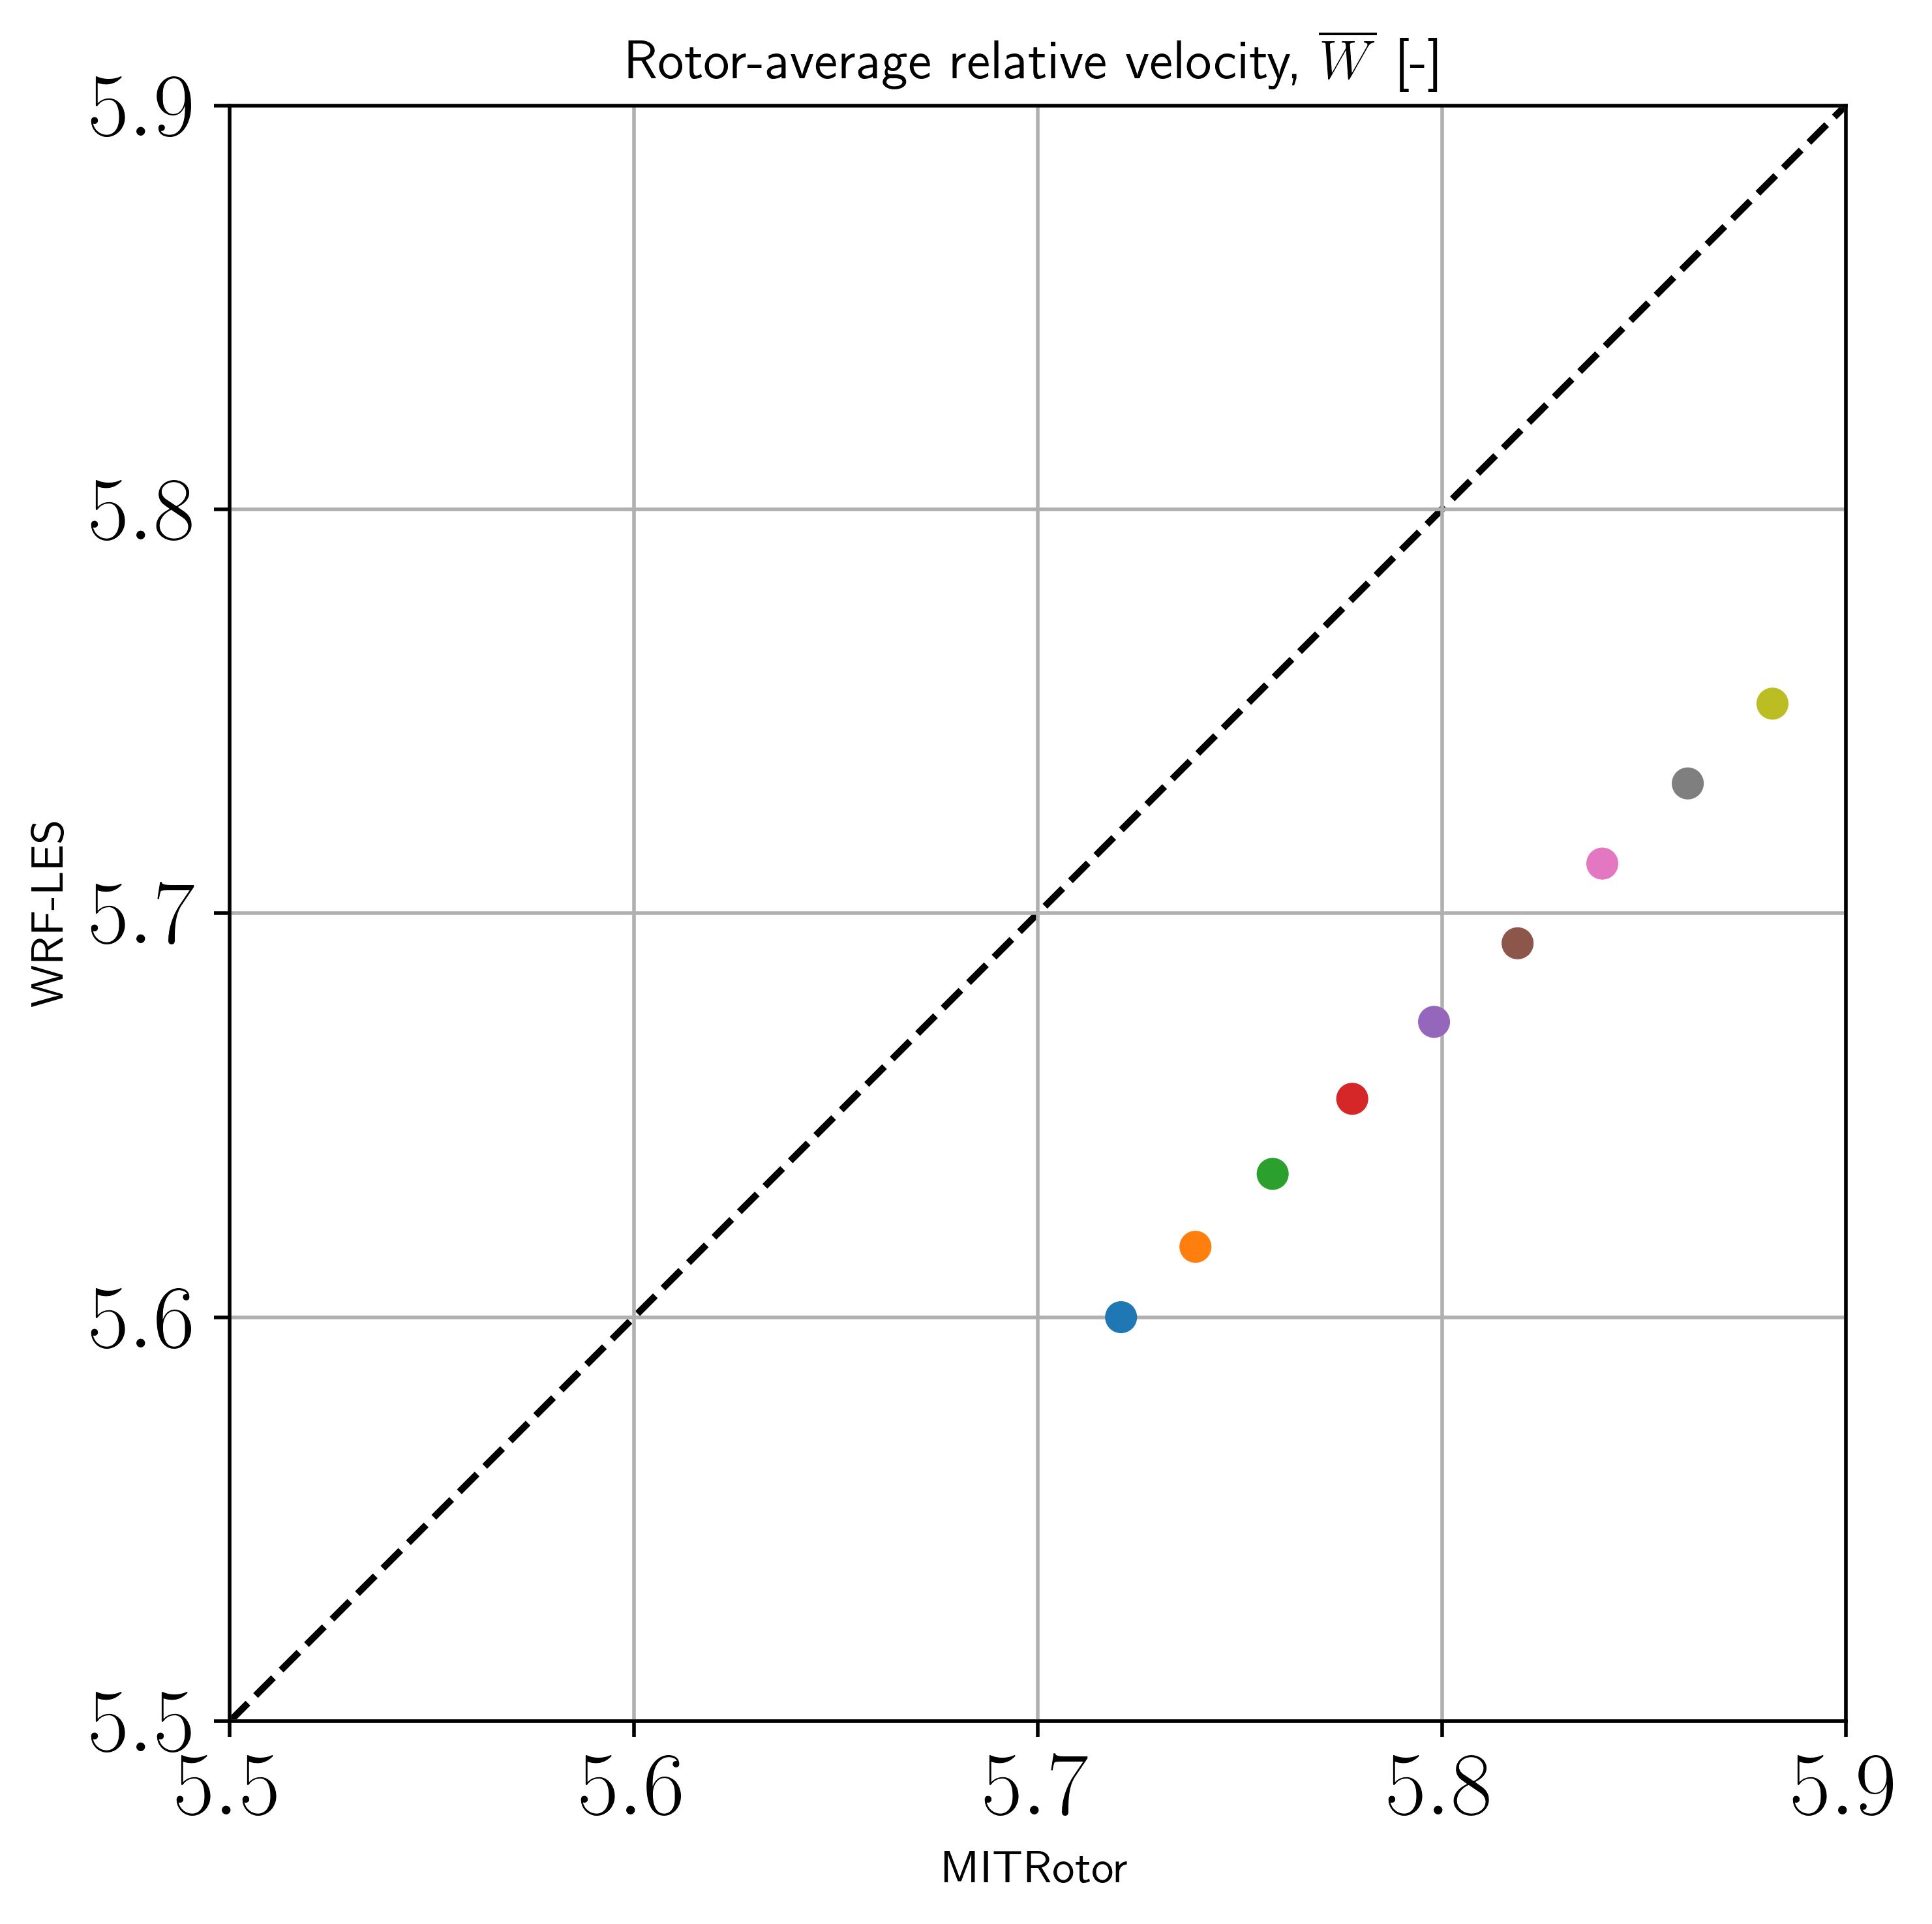

In [90]:
# Create plot
fig,ax = plt.subplots(figsize=(8, 6))
for i in range(len(mit_w)):
    ax.scatter(mit_w[i], wrf_rel_ss[i], s=50, edgecolor='none', color=colors[i],zorder=i+2)
ax.plot([0,10],[0,10],color='k',linestyle='--',zorder=1)

ax.set_xlim([5.5,5.9])
ax.set_ylim([5.5,5.9])
ax.set_aspect('equal')

plt.title(r"Rotor-average relative velocity, $\overline{W}$ [-]")
plt.xlabel("MITRotor")
plt.ylabel("WRF-LES")
plt.grid(True)
plt.tight_layout()
plt.show()

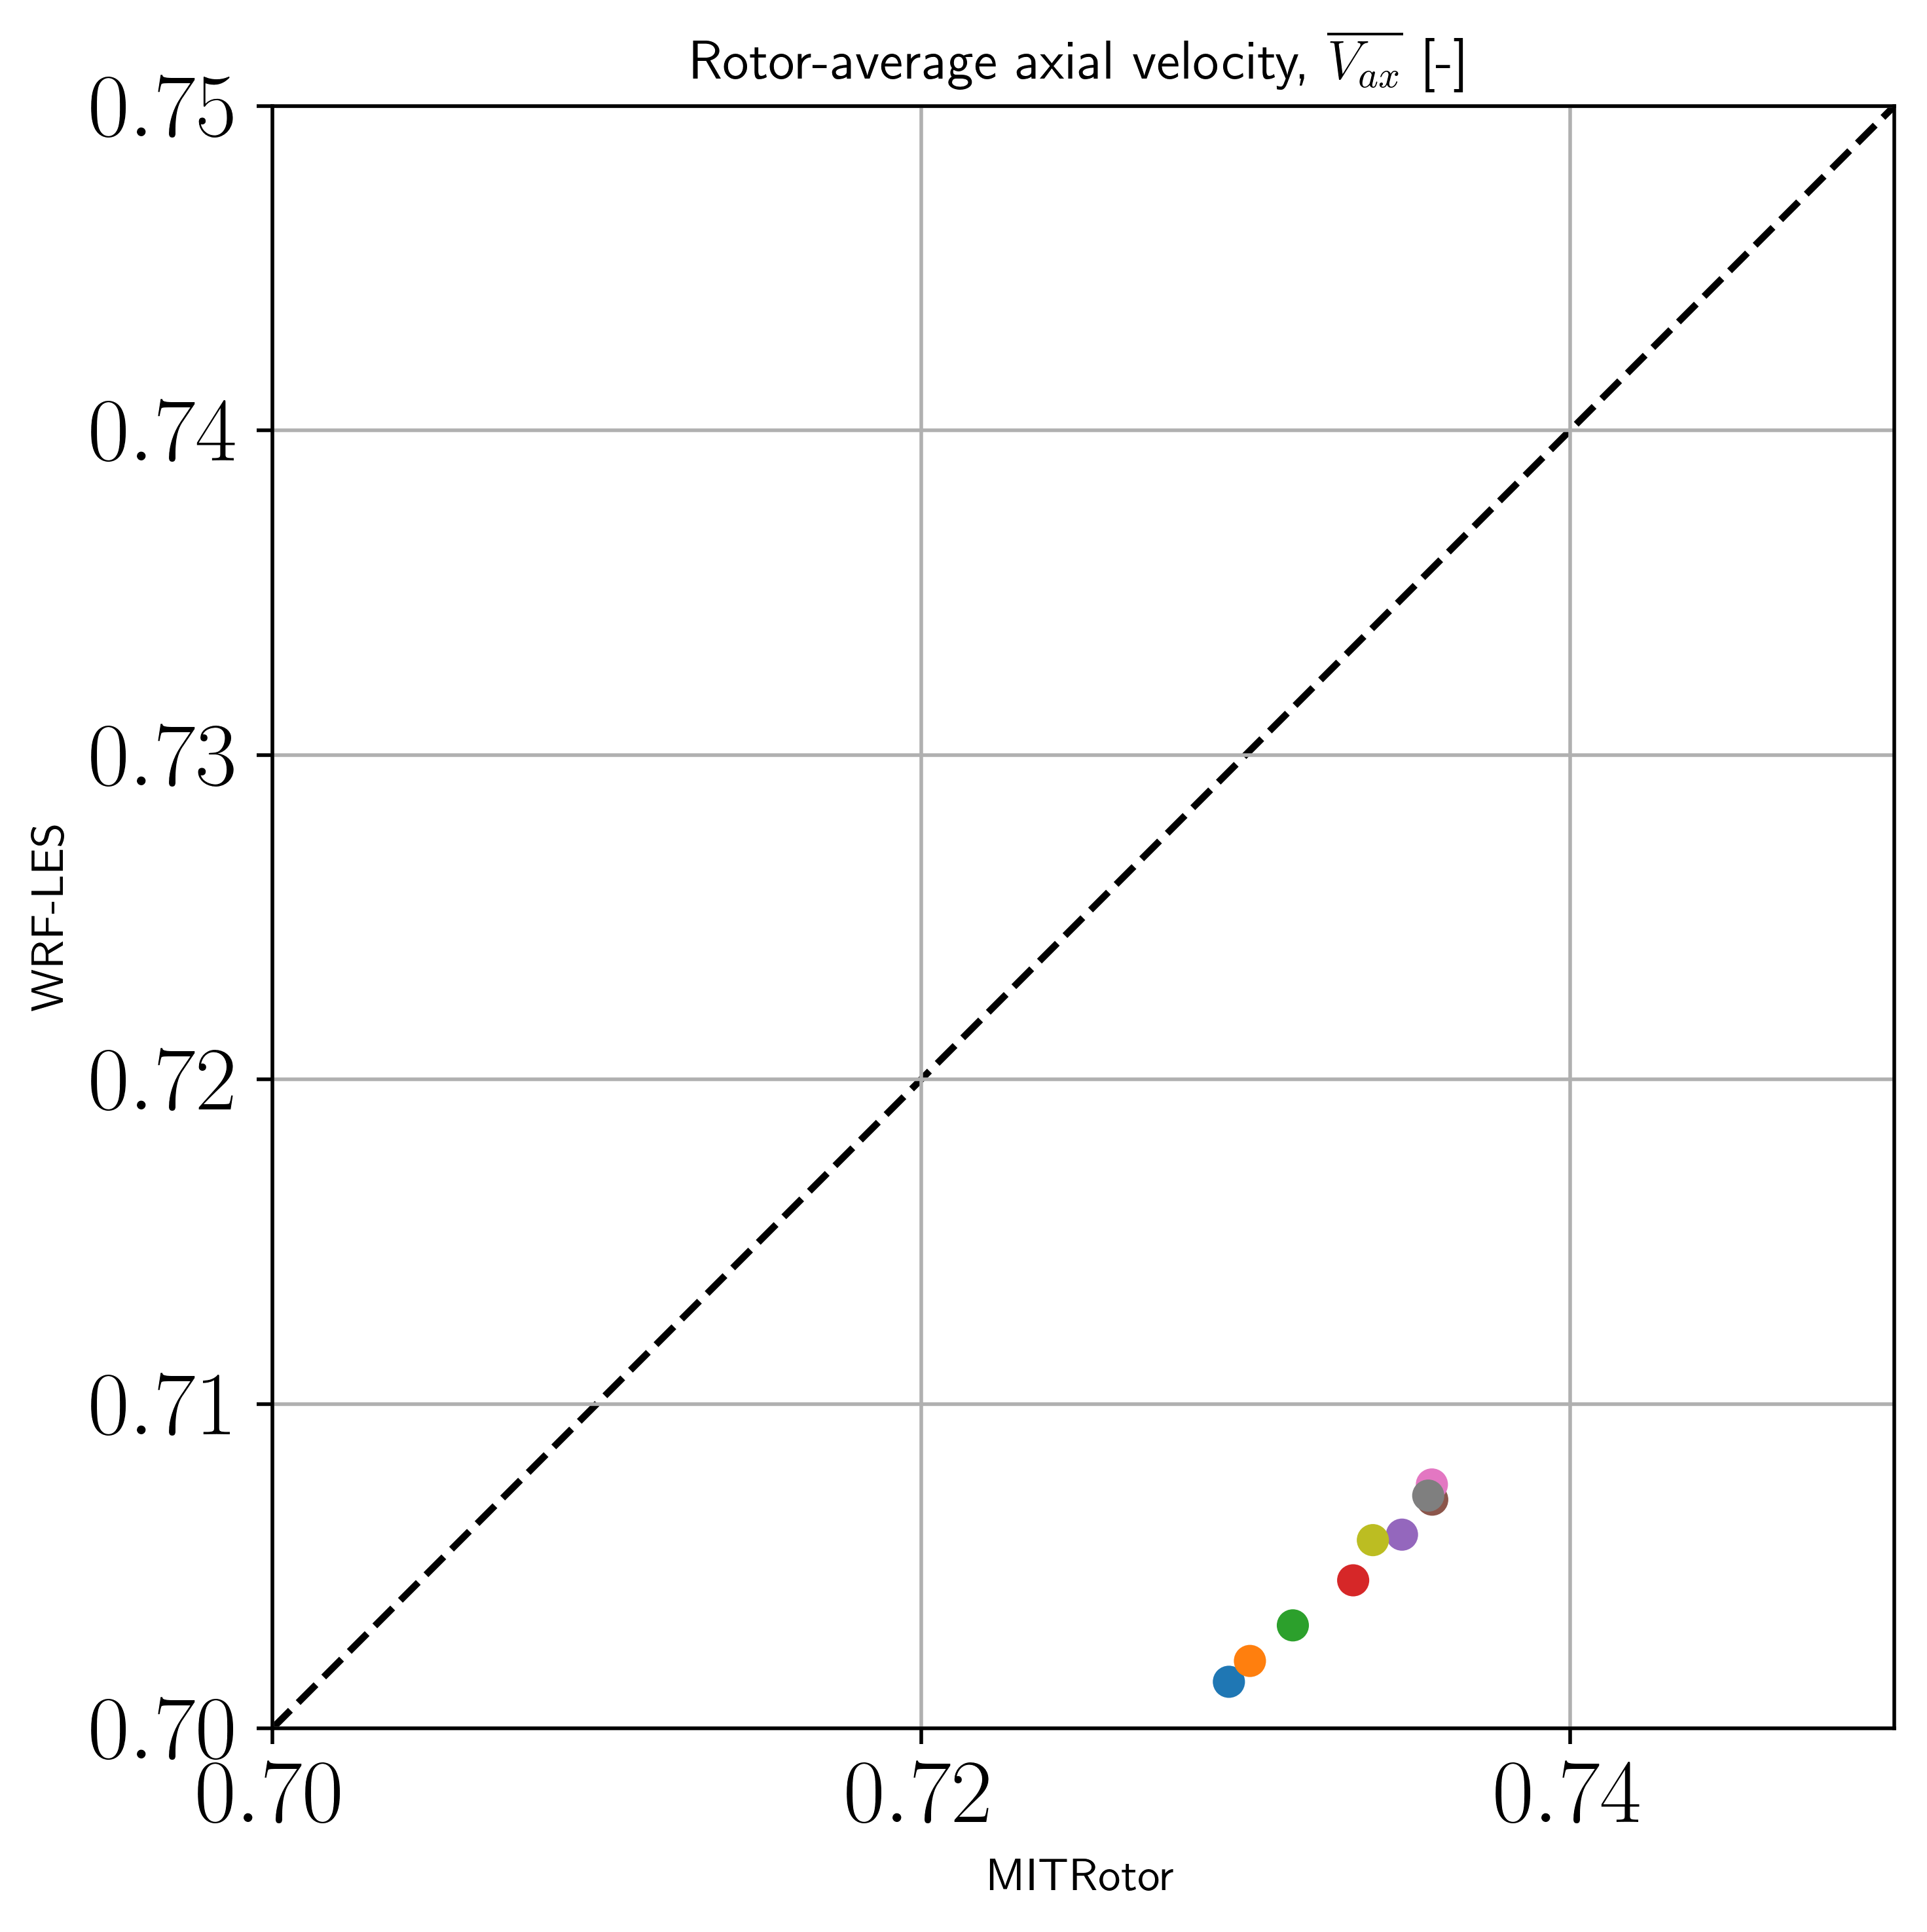

In [91]:
# Create plot
fig,ax = plt.subplots(figsize=(8, 6))
for i in range(len(mit_vax)):
    ax.scatter(mit_vax[i], wrf_vax_ss[i], s=50, edgecolor='none', color=colors[i], zorder=i+2)
ax.plot([0,10],[0,10],color='k',linestyle='--',zorder=1)

ax.set_xlim([0.7,0.75])
ax.set_ylim([0.7,0.75])
ax.set_aspect('equal')

plt.title(r"Rotor-average axial velocity, $\overline{V_{ax}}$ [-]")
plt.xlabel("MITRotor")
plt.ylabel("WRF-LES")
plt.grid(True)
plt.tight_layout()
plt.show()

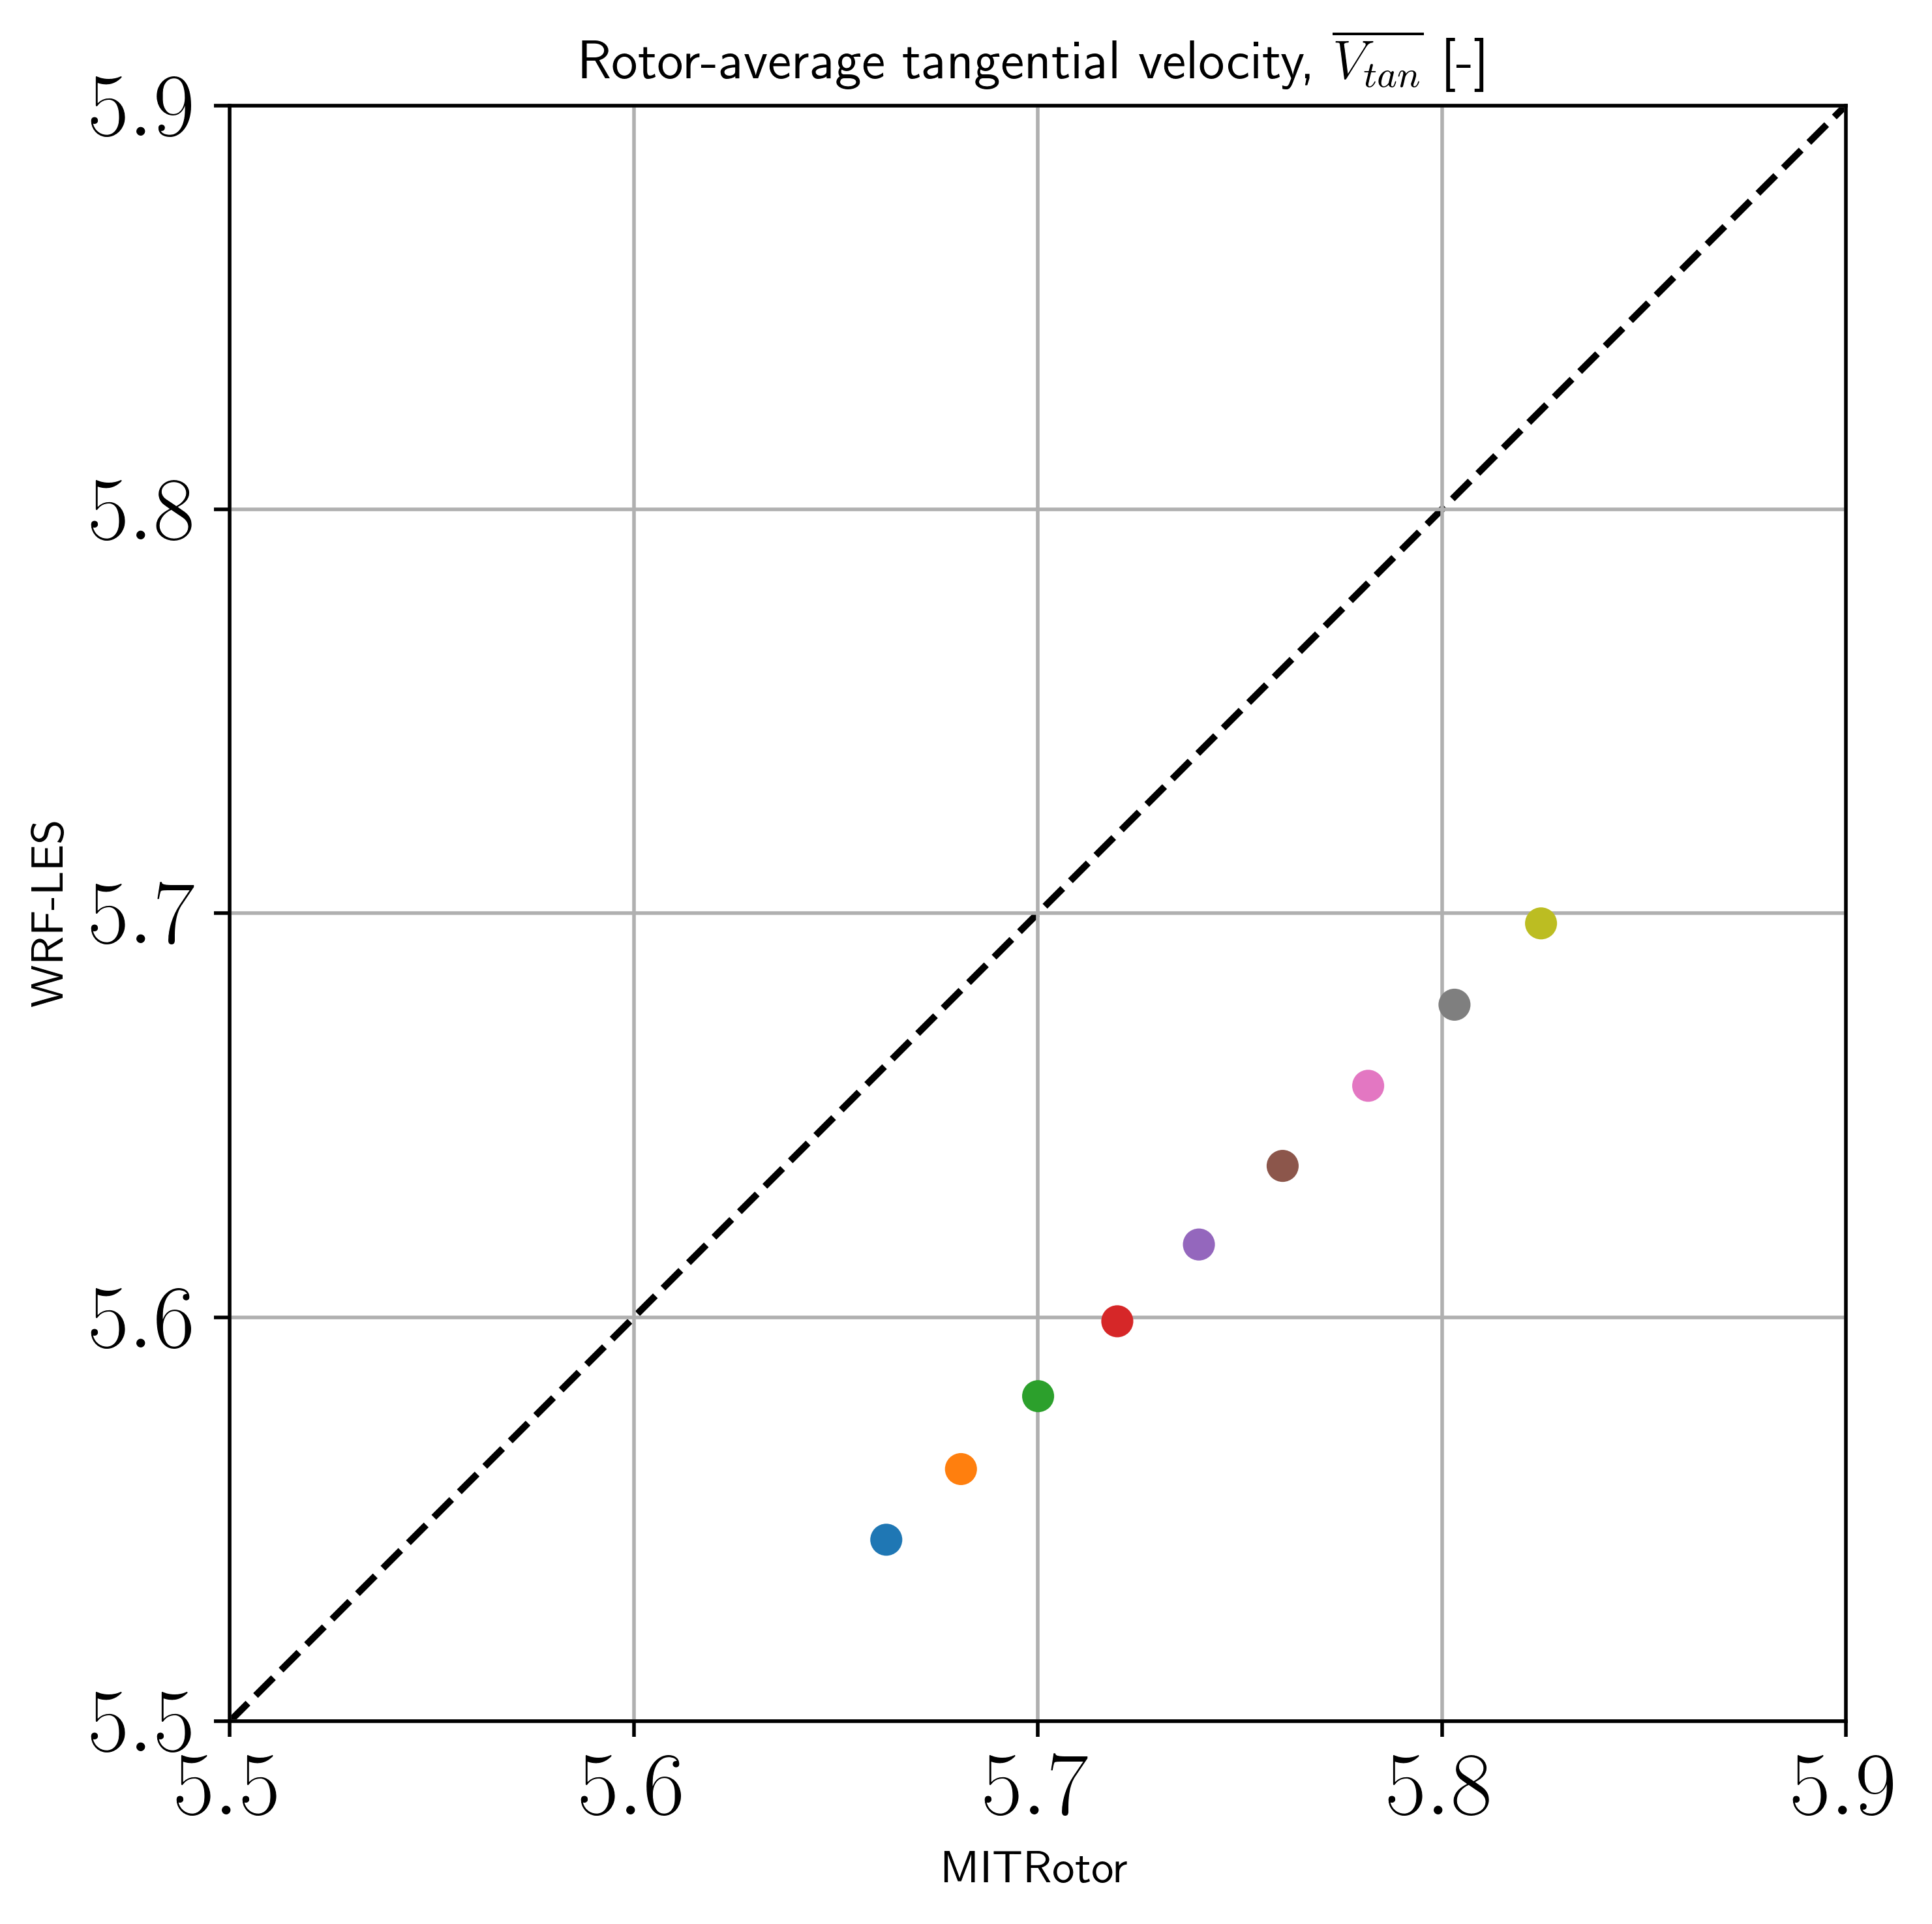

In [92]:
# Create plot
fig,ax = plt.subplots(figsize=(8, 6))
for i in range(len(mit_vtn)):
    ax.scatter(mit_vtn[i], wrf_vtn_ss[i], s=50, edgecolor='none', color=colors[i],zorder=i+2)
ax.plot([0,10],[0,10],color='k',linestyle='--',zorder=1)

ax.set_xlim([5.5,5.9])
ax.set_ylim([5.5,5.9])
ax.set_aspect('equal')

plt.title(r"Rotor-average tangential velocity, $\overline{V_{tan}}$ [-]")
plt.xlabel("MITRotor")
plt.ylabel("WRF-LES")
plt.grid(True)
plt.tight_layout()
plt.show()